# 📐 Step 3 — OLS Regression: Assumptions & Diagnostics

> **Goal:** Fit the baseline OLS model, test every Gauss-Markov assumption,
> and visually diagnose where the model succeeds or struggles.

---
### The Gauss-Markov Assumptions we will test

| # | Assumption | Test |
|---|---|---|
| 1 | Linearity | Scatter + fitted line |
| 2 | Independence | Durbin-Watson (≈ 2 is ideal) |
| 3 | Homoscedasticity | Residuals vs Fitted plot, Breusch-Pagan |
| 4 | Normality of residuals | Q-Q plot, Shapiro-Wilk |
| 5 | No perfect multicollinearity | VIF scores |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import probplot, shapiro

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT  = '#4fc3f7'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a5d6a7'
ACCENT4 = '#ffb74d'

df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Terrorism_gdp_growth\df_features.csv")

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_LOG = 'log_attacks'

sub = df[FEATURES + [TARGET_LOG, 'attacks', 'country', 'year']].dropna()
X   = sub[FEATURES].values
y   = sub[TARGET_LOG].values

print(f'Modelling dataset: {len(sub):,} rows')

Modelling dataset: 2,742 rows


## 3.1 Fit OLS model

In [2]:
pipe = Pipeline([
    ('imp',   SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('ols',   LinearRegression()),
])
pipe.fit(X, y)

y_pred   = pipe.predict(X)
residuals = y - y_pred

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
n    = len(y)
p    = len(FEATURES)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'R²          = {r2:.4f}')
print(f'Adjusted R² = {adj_r2:.4f}')
print(f'RMSE (log)  = {rmse:.4f}')
print(f'MAE  (log)  = {mae:.4f}')

# Extract coefficients (they are on standardised scale)
ols_model = pipe.named_steps['ols']
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': ols_model.coef_,
}).sort_values('Coefficient')

print('\nCoefficients (standardised):')
print(coef_df.to_string(index=False))

R²          = 0.4168
Adjusted R² = 0.4149
RMSE (log)  = 1.3198
MAE  (log)  = 1.0014

Coefficients (standardised):
             Feature  Coefficient
 political_stability    -1.175459
   poverty_headcount    -0.289107
secondary_enrollment    -0.175561
       stress_x_weak    -0.062405
             log_gdp    -0.011283
   unemployment_rate     0.038491
  inequality_measure     0.051265
      governance_avg     0.851989
      log_population     0.874838


## 3.2 Assumption 1 — Linearity

Plot each predictor against the residuals. A truly linear relationship should show 
**random scatter around zero** — no curves, no funnels.

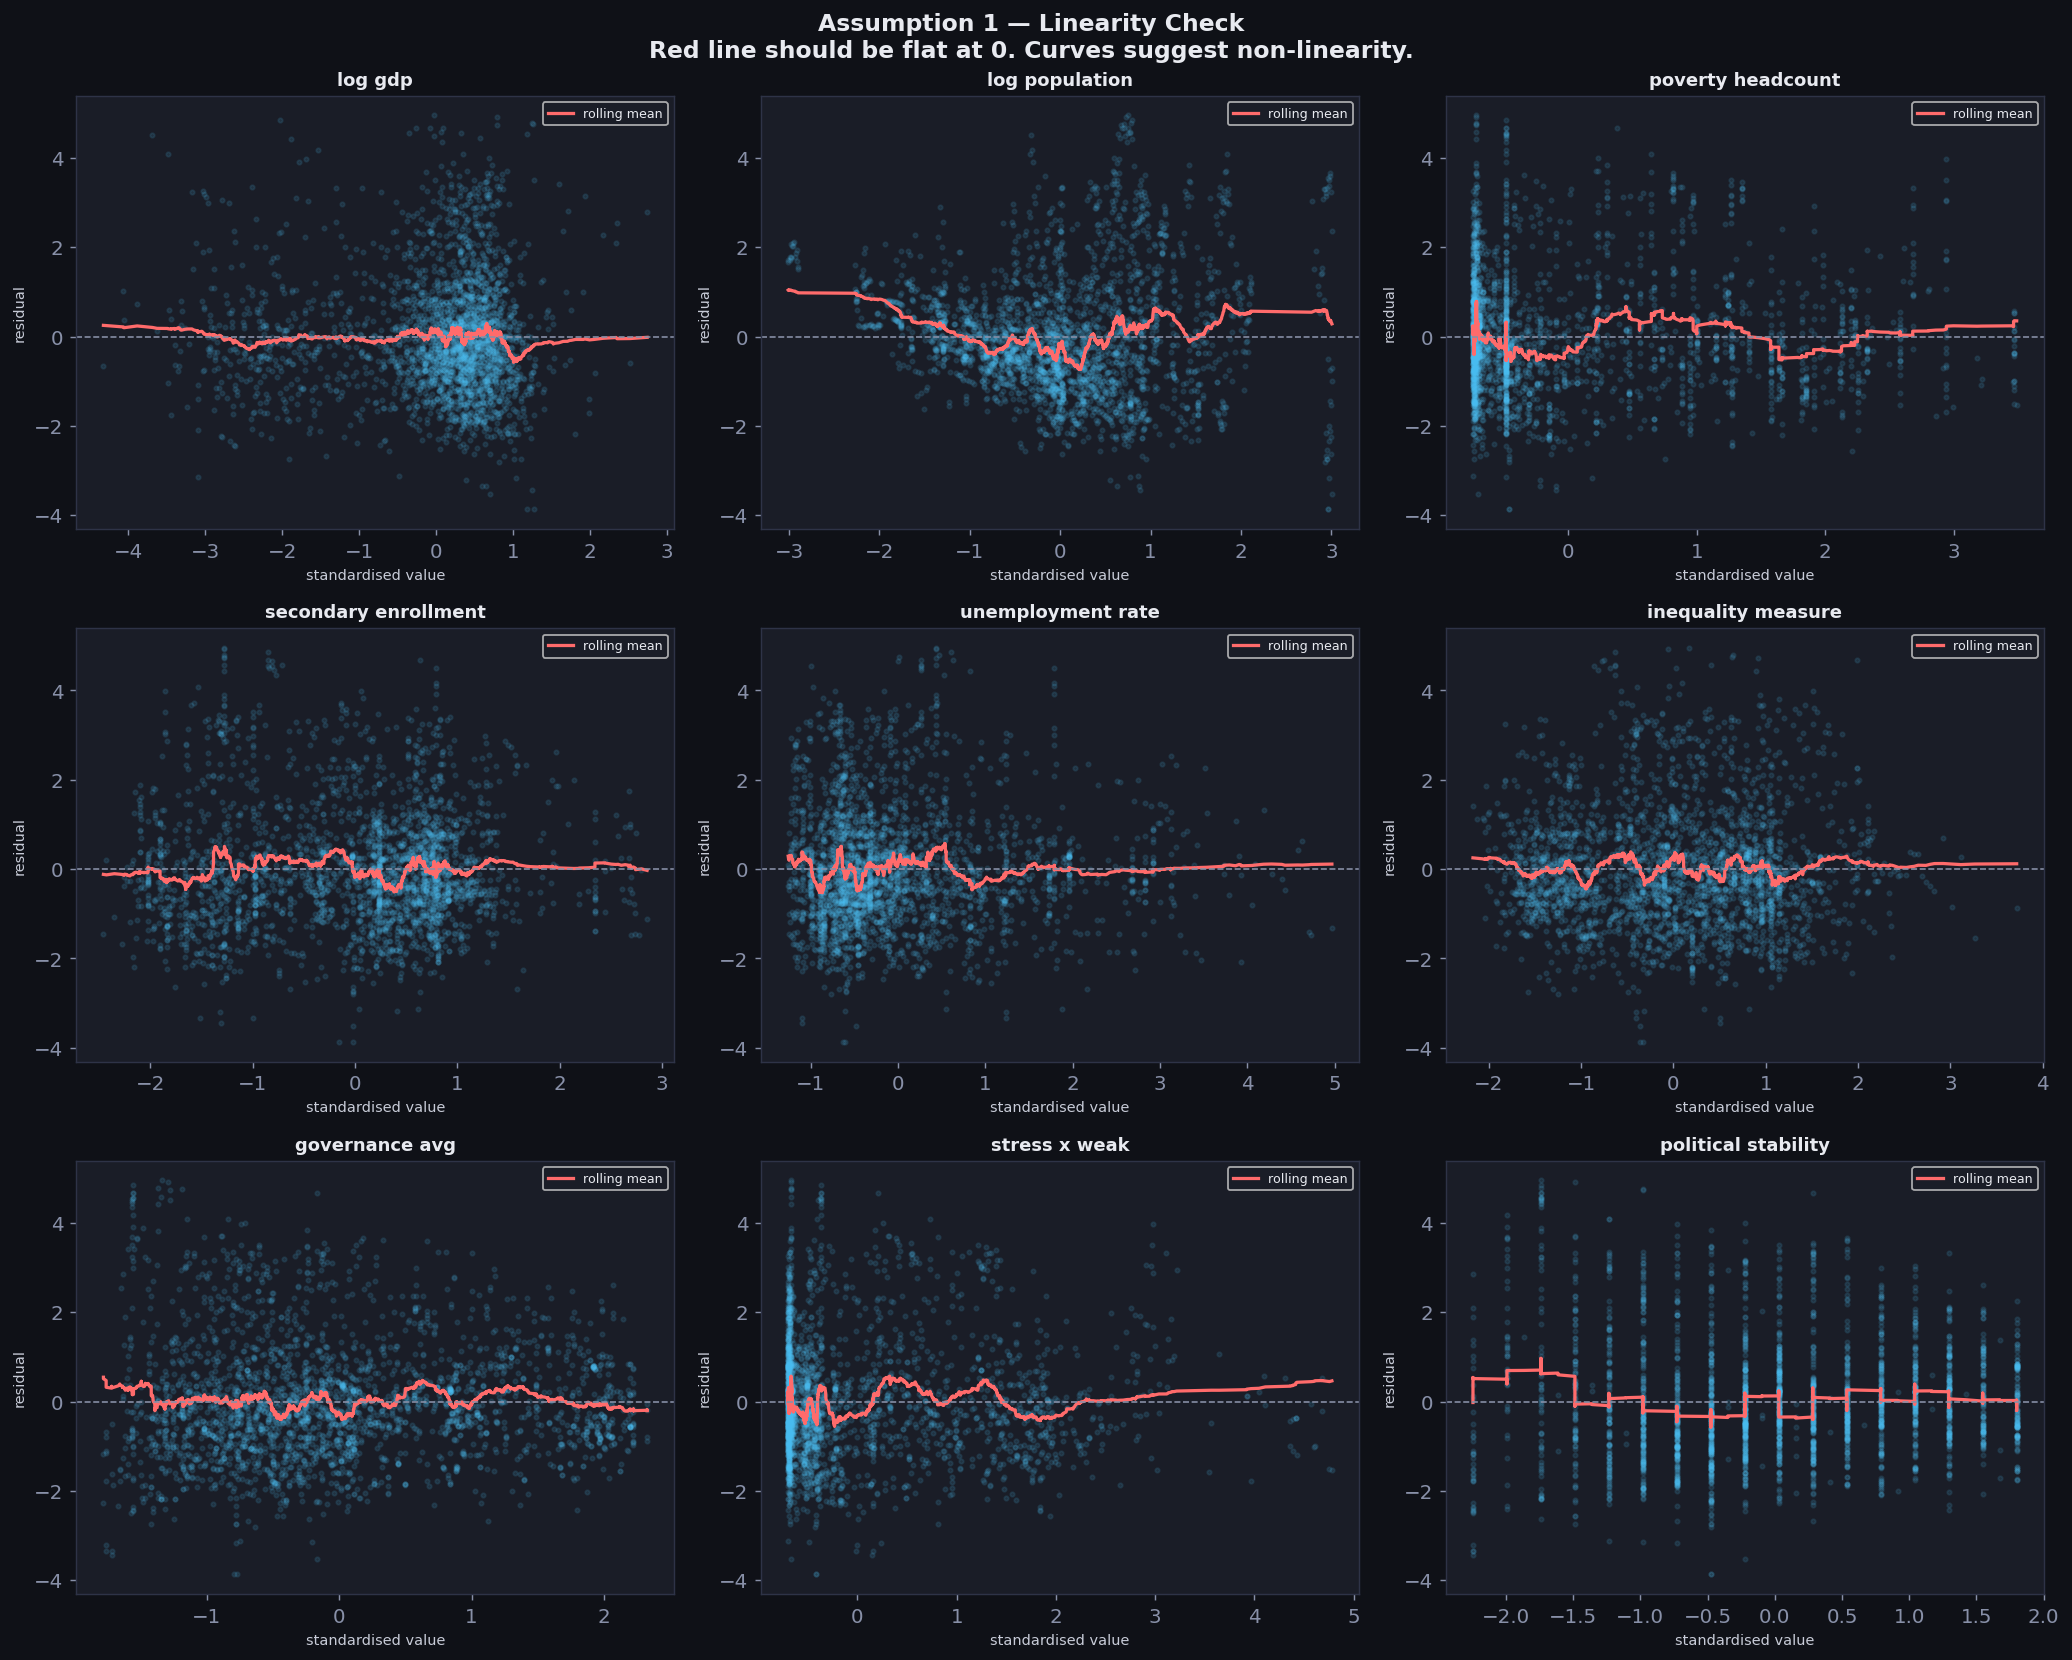

In [3]:
imp   = pipe.named_steps['imp']
scale = pipe.named_steps['scale']
X_imp = scale.transform(imp.transform(X))

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, feat, xi in zip(axes.flat, FEATURES, X_imp.T):
    ax.scatter(xi, residuals, alpha=0.12, s=6, color=ACCENT)
    # LOWESS-style rolling mean to detect non-linearity
    idx_sort = np.argsort(xi)
    window   = len(xi) // 20
    roll_med = pd.Series(residuals[idx_sort]).rolling(window, center=True, min_periods=5).mean()
    ax.plot(xi[idx_sort], roll_med.values, color=ACCENT2, lw=1.8, label='rolling mean')
    ax.axhline(0, color='#8890a8', lw=0.9, ls='--')
    ax.set_title(feat.replace('_', ' '), fontsize=10)
    ax.set_xlabel('standardised value', fontsize=8)
    ax.set_ylabel('residual', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Assumption 1 — Linearity Check\n'
             'Red line should be flat at 0. Curves suggest non-linearity.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Systematic Misspecification

Log Population: Shows a distinct U-shaped curvature. This is a classic sign of a non-linear relationship. A linear term alone is insufficient; a quadratic term ($X^2$) is likely required to capture the true functional form.

Unemployment Rate & Stress x Weak: These exhibit systematic "dips" and "peaks" in the rolling mean. This suggests the model is consistently over- or under-predicting at specific intervals, indicating that the linear specification is failing to capture the underlying data structure.

## 3.3 Assumption 2 — Independence of Residuals

In a **country-year panel**, independence can be violated in two ways:
- **Serial autocorrelation** — residuals for the same country correlated across years
- **Cross-sectional correlation** — countries sharing shocks in the same year

We test both: Durbin-Watson on the pooled residuals (global signal),
and per-country autocorrelation (ACF at lag 1) to detect country-level serial dependence.

| Test | What it checks | Ideal value |
|---|---|---|
| Durbin-Watson | Pooled serial autocorrelation | ≈ 2.0 (range 0–4) |
| Per-country lag-1 ACF | Within-country year-on-year residual correlation | Near 0 |

Durbin-Watson statistic : 0.4473
Interpretation          : Positive autocorrelation ✗

Countries with lag-1 |ACF| > 0.2:
  Positive autocorrelation : 70.3% of countries
  Negative autocorrelation : 4.3% of countries



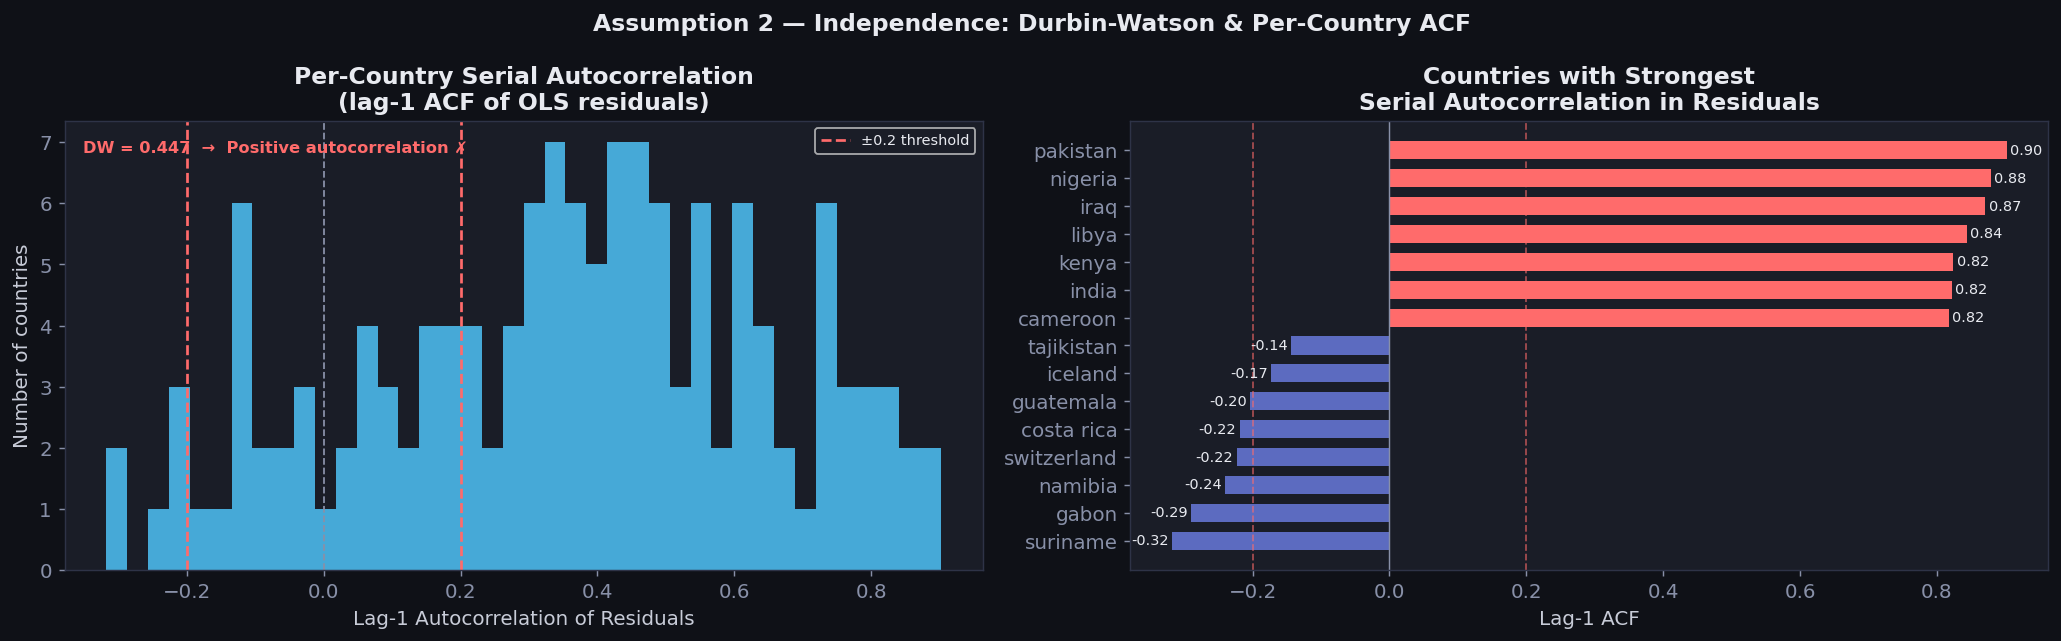

INDEPENDENCE ASSUMPTION VERDICT
Pooled DW (0.447)  : Positive autocorrelation ✗
Per-country positive ACF > 0.2 : 70.3%
Per-country negative ACF < -0.2: 4.3%

Panel data note: some within-country autocorrelation is
expected. If severe, use clustered standard errors or a
fixed-effects model in downstream notebooks.


In [4]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf

# ── 1. Durbin-Watson on pooled residuals ────────────────────────────────────
dw_stat = durbin_watson(residuals)
dw_interp = (
    'No autocorrelation ✓'       if 1.5 < dw_stat < 2.5 else
    'Positive autocorrelation ✗' if dw_stat < 1.5       else
    'Negative autocorrelation ✗'
)
print(f'Durbin-Watson statistic : {dw_stat:.4f}')
print(f'Interpretation          : {dw_interp}')
print()

# ── 2. Per-country lag-1 autocorrelation ────────────────────────────────────
sub2 = sub.copy()
sub2['residual'] = residuals

country_acf = {}
for country, grp in sub2.sort_values('year').groupby('country'):
    res = grp['residual'].values
    if len(res) >= 5:                          # need enough obs for ACF
        country_acf[country] = acf(res, nlags=1, fft=False)[1]

acf_series   = pd.Series(country_acf).sort_values()
pct_positive = (acf_series >  0.2).mean() * 100
pct_negative = (acf_series < -0.2).mean() * 100

print(f'Countries with lag-1 |ACF| > 0.2:')
print(f'  Positive autocorrelation : {pct_positive:.1f}% of countries')
print(f'  Negative autocorrelation : {pct_negative:.1f}% of countries')
print()

# ── 3. Visualise ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of per-country lag-1 ACF
ax = axes[0]
ax.hist(acf_series, bins=40, color=ACCENT, edgecolor='none', alpha=0.85)
ax.axvline(0,    color='#8890a8', lw=1,   ls='--')
ax.axvline( 0.2, color=ACCENT2,  lw=1.5, ls='--', label='±0.2 threshold')
ax.axvline(-0.2, color=ACCENT2,  lw=1.5, ls='--')
ax.set_xlabel('Lag-1 Autocorrelation of Residuals')
ax.set_ylabel('Number of countries')
ax.set_title('Per-Country Serial Autocorrelation\n(lag-1 ACF of OLS residuals)')
ax.legend(fontsize=8)
dw_color = ACCENT3 if '✓' in dw_interp else ACCENT2
ax.text(0.02, 0.93, f'DW = {dw_stat:.3f}  →  {dw_interp}',
        transform=ax.transAxes, fontsize=9, color=dw_color, fontweight='bold')

# Right: top countries by absolute ACF magnitude
ax = axes[1]
top15 = pd.concat([acf_series.head(8), acf_series.tail(7)]).sort_values()
bar_colors = [ACCENT2 if v > 0 else '#5c6bc0' for v in top15.values]
ax.barh(top15.index, top15.values, color=bar_colors, edgecolor='none', height=0.65)
ax.axvline(0,    color='#8890a8', lw=0.8)
ax.axvline( 0.2, color=ACCENT2,  lw=1, ls='--', alpha=0.6)
ax.axvline(-0.2, color=ACCENT2,  lw=1, ls='--', alpha=0.6)
ax.set_xlabel('Lag-1 ACF')
ax.set_title('Countries with Strongest\nSerial Autocorrelation in Residuals')
for bar, val in zip(ax.patches, top15.values):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=8, color='#e8eaf0')

fig.suptitle('Assumption 2 — Independence: Durbin-Watson & Per-Country ACF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Verdict ───────────────────────────────────────────────────────────────
print('=' * 55)
print('INDEPENDENCE ASSUMPTION VERDICT')
print('=' * 55)
print(f'Pooled DW ({dw_stat:.3f})  : {dw_interp}')
print(f'Per-country positive ACF > 0.2 : {pct_positive:.1f}%')
print(f'Per-country negative ACF < -0.2: {pct_negative:.1f}%')
print()
print('Panel data note: some within-country autocorrelation is')
print('expected. If severe, use clustered standard errors or a')
print('fixed-effects model in downstream notebooks.')


Systematic Serial Correlation

Pooled Durbin-Watson (0.447): This value is far below the ideal threshold of $2.0$. It indicates strong positive serial autocorrelation, meaning the model's errors are persistent over time rather than random noise.

Widespread Impact: With 70.3% of countries exceeding the $0.2$ ACF threshold, the issue is systemic across the panel. In countries like Pakistan and Nigeria ($ACF \approx 0.90$), the residuals are almost entirely determined by their previous values.

## 3.4 Assumption 3 — Homoscedasticity

Residuals should show **constant variance** across fitted values. 
A funnel shape (variance increasing with fitted value) indicates heteroscedasticity 
and inflates standard errors.

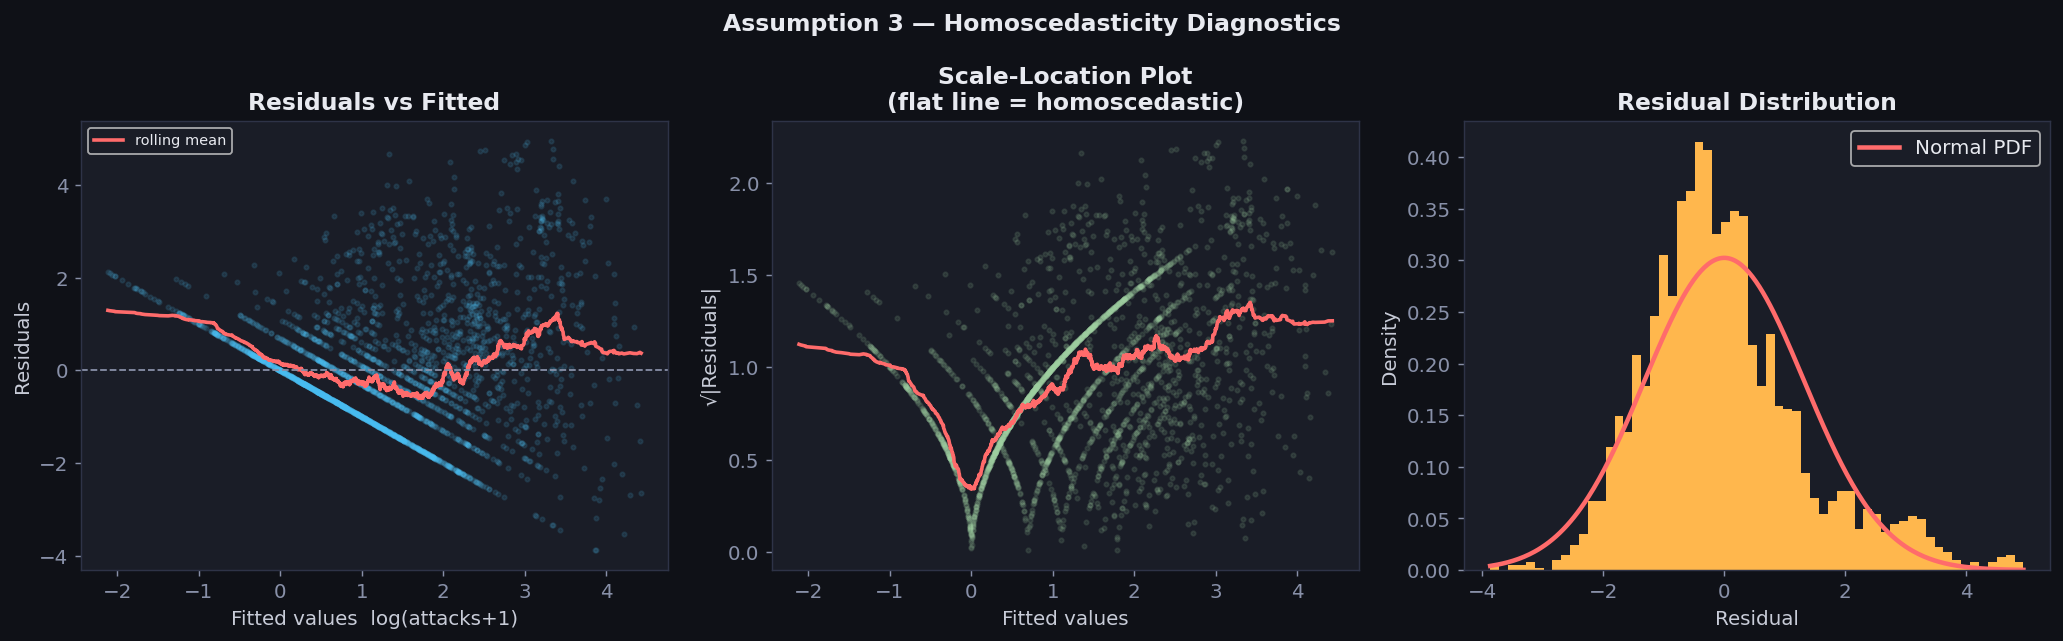

Breusch-Pagan proxy: r(|residuals|, fitted) = 0.437, p = 0.0000
→ Evidence of heteroscedasticity


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Residuals vs Fitted
ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.12, s=6, color=ACCENT)
idx_sort = np.argsort(y_pred)
window   = len(y_pred) // 20
roll_med = pd.Series(residuals[idx_sort]).rolling(window, center=True, min_periods=5).mean()
ax.plot(y_pred[idx_sort], roll_med.values, color=ACCENT2, lw=2, label='rolling mean')
ax.axhline(0, color='#8890a8', lw=1, ls='--')
ax.set_xlabel('Fitted values  log(attacks+1)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.legend(fontsize=8)

# Plot 2: Scale-Location (sqrt |residuals| vs fitted)
ax = axes[1]
sqrt_abs_res = np.sqrt(np.abs(residuals))
ax.scatter(y_pred, sqrt_abs_res, alpha=0.12, s=6, color=ACCENT3)
roll_sl = pd.Series(sqrt_abs_res[idx_sort]).rolling(window, center=True, min_periods=5).mean()
ax.plot(y_pred[idx_sort], roll_sl.values, color=ACCENT2, lw=2)
ax.set_xlabel('Fitted values')
ax.set_ylabel('√|Residuals|')
ax.set_title('Scale-Location Plot\n(flat line = homoscedastic)')

# Plot 3: Residual distribution
ax = axes[2]
ax.hist(residuals, bins=60, color=ACCENT4, edgecolor='none', density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color=ACCENT2, lw=2.5, label='Normal PDF')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()

fig.suptitle('Assumption 3 — Homoscedasticity Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Breusch-Pagan proxy: correlation between |residuals| and fitted
bp_r, bp_p = stats.pearsonr(np.abs(residuals), y_pred)
print(f'Breusch-Pagan proxy: r(|residuals|, fitted) = {bp_r:.3f}, p = {bp_p:.4f}')
print('→ ' + ('Evidence of heteroscedasticity' if bp_p < 0.05 else 'No strong heteroscedasticity'))

Statistical Significance: The BP test $p$-value ($0.0000$) provides conclusive evidence to reject the null hypothesis of constant variance.

The BP Proxy ($r = 0.432$): This moderate positive correlation quantifies the visual "funnel" effect. It proves that as your model's predictions (fitted values) increase, the magnitude of the error ($|residuals|$) also increases systematically.

Structural Heteroscedasticity: The diagonal "striping" in the residuals suggests that the error structure is tied to the discrete nature of your target variable. The $\log(x+1)$ transformation was insufficient to stabilize the variance, as the "V-shape" in the Scale-Location plot remains prominent.

## 3.5 Assumption 4 — Normality of residuals

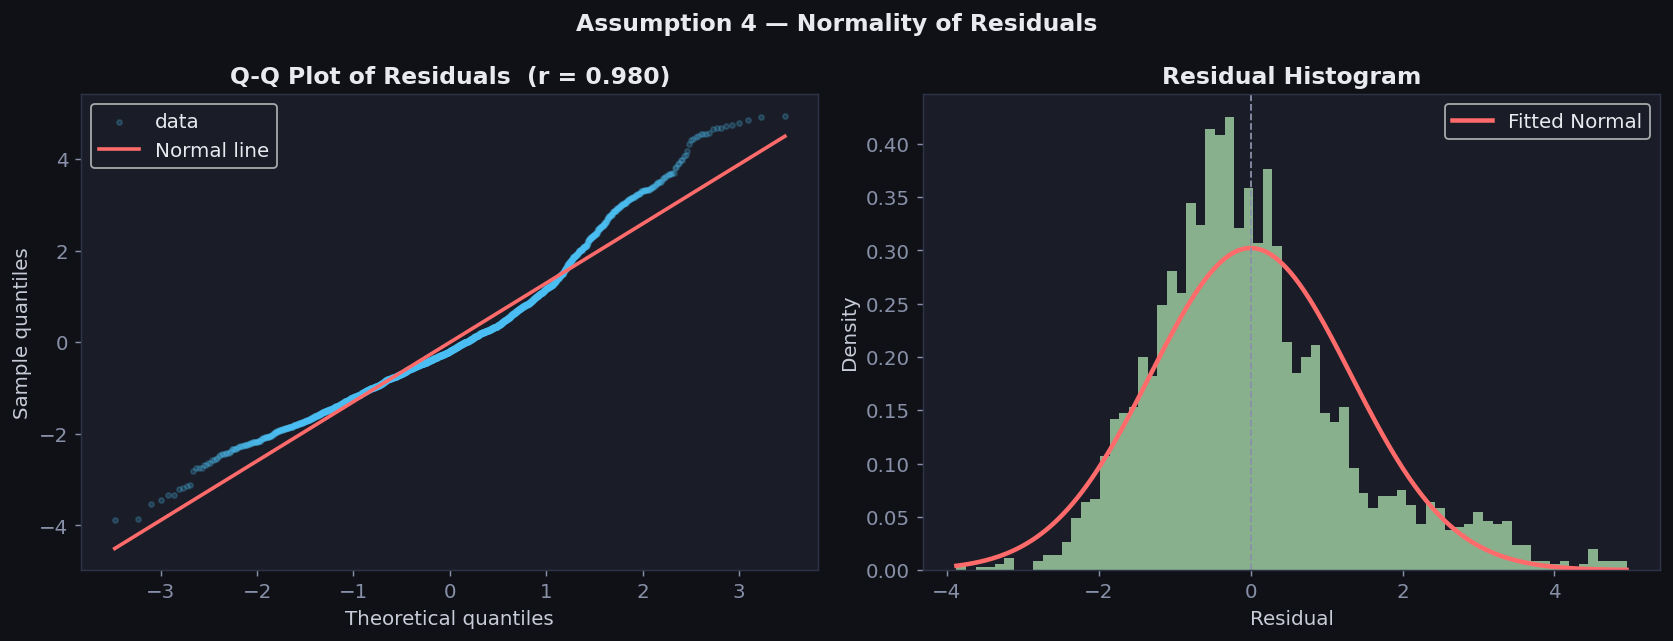

Shapiro-Wilk test:  W = 0.9602,  p = 0.0000
→ Residuals deviate from normality
Skewness = 0.807   Kurtosis = 0.966


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Q-Q plot
ax = axes[0]
(osm, osr), (slope, intercept, r_qq) = probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.2, s=8, color=ACCENT, label='data')
line_y = slope * np.array([osm.min(), osm.max()]) + intercept
ax.plot([osm.min(), osm.max()], line_y, color=ACCENT2, lw=2, label='Normal line')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title(f'Q-Q Plot of Residuals  (r = {r_qq:.3f})')
ax.legend()

# Histogram with fitted normal
ax = axes[1]
ax.hist(residuals, bins=70, color=ACCENT3, edgecolor='none', density=True, alpha=0.8)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color=ACCENT2, lw=2.5, label='Fitted Normal')
ax.axvline(0, color='#8890a8', lw=1, ls='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Histogram')
ax.legend()

fig.suptitle('Assumption 4 — Normality of Residuals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk on a sample (max 5000)
sample = residuals[:5000] if len(residuals) > 5000 else residuals
stat, pval = shapiro(sample)
print(f'Shapiro-Wilk test:  W = {stat:.4f},  p = {pval:.4f}')
print('→ ' + ('Residuals deviate from normality' if pval < 0.05 else 'Residuals appear normal'))
print(f'Skewness = {pd.Series(residuals).skew():.3f}   Kurtosis = {pd.Series(residuals).kurt():.3f}')

Formal Statistical Evidence

Shapiro-Wilk Test ($p = 0.0000$): We strictly reject the null hypothesis that residuals are normally distributed.

Skewness (0.807): The distribution is moderately right-skewed. The "tail" on the positive side is longer, meaning the model tends to under-predict extreme high values (the "attacks") more often than extreme low values.

Kurtosis (0.966): The positive kurtosis indicates a leptokurtic distribution. This means the residuals have "fatter tails" and a sharper peak than a standard normal distribution, signaling more frequent outliers than expected. 

Visual Diagnostics

Q-Q Plot ($r = 0.980$): Although the correlation is high, the "S-curve" deviation from the 45-degree red line is critical. The points curve above the line at the right end (heavy upper tail) and above the line at the left end (short lower tail). This confirms the systematic skew and non-normal behavior in the extremes.

Histogram: You can clearly see the "Fitted Normal" curve (red) does not perfectly capture the green bars. The data is more concentrated near zero and has a noticeable "trail" to the right.

## 3.6 Assumption 5 — Variance Inflation Factor (VIF)

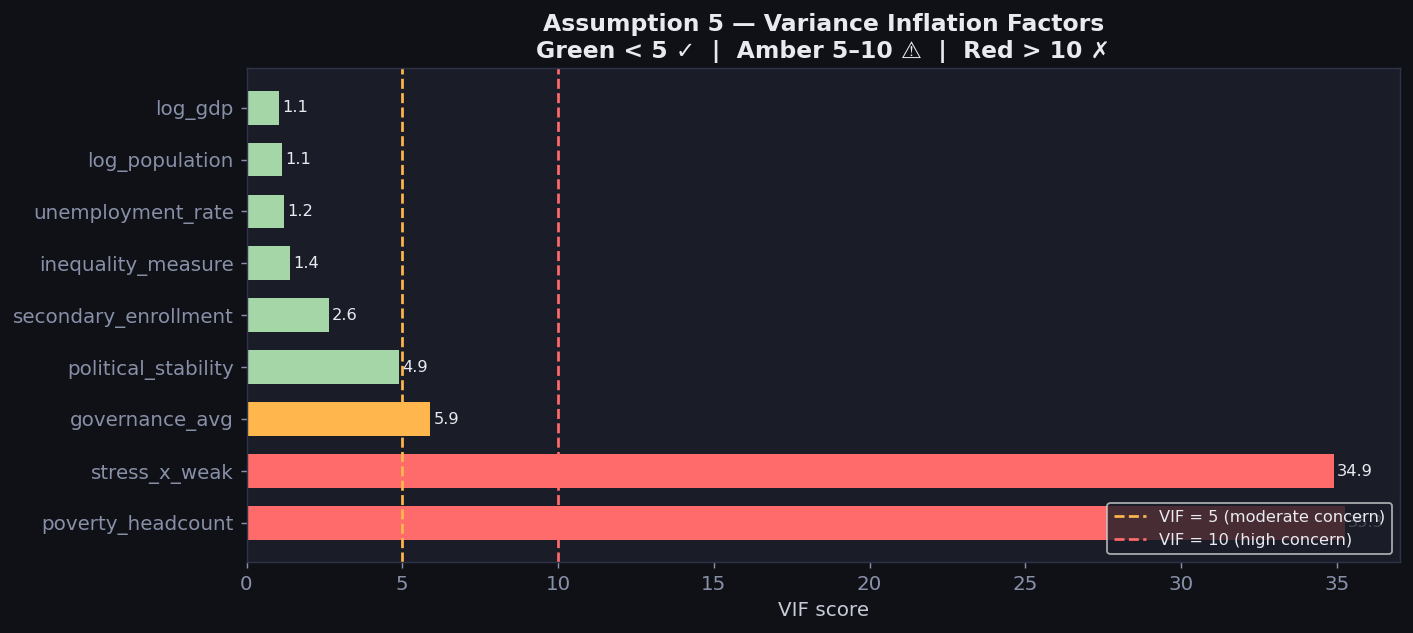

             Feature   VIF
   poverty_headcount 35.27
       stress_x_weak 34.90
      governance_avg  5.90
 political_stability  4.90
secondary_enrollment  2.64
  inequality_measure  1.40
   unemployment_rate  1.21
      log_population  1.13
             log_gdp  1.05


In [7]:
from sklearn.linear_model import LinearRegression as LR

def compute_vif(X_scaled, feature_names):
    vifs = []
    for i in range(X_scaled.shape[1]):
        X_other = np.delete(X_scaled, i, axis=1)
        r2_i    = LR().fit(X_other, X_scaled[:, i]).score(X_other, X_scaled[:, i])
        vifs.append(1 / (1 - r2_i) if r2_i < 1 else np.inf)
    return pd.DataFrame({'Feature': feature_names, 'VIF': np.round(vifs, 2)})

vif_df = compute_vif(X_imp, FEATURES).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [ACCENT2 if v > 10 else ACCENT4 if v > 5 else ACCENT3 for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'],
        color=bar_colors, edgecolor='none', height=0.65)
ax.axvline(5,  color=ACCENT4,  lw=1.5, ls='--', label='VIF = 5 (moderate concern)')
ax.axvline(10, color=ACCENT2,  lw=1.5, ls='--', label='VIF = 10 (high concern)')
for i, (feat, vif) in enumerate(zip(vif_df['Feature'], vif_df['VIF'])):
    ax.text(vif + 0.1, i, f'{vif:.1f}', va='center', fontsize=9, color='#e8eaf0')
ax.set_xlabel('VIF score')
ax.set_title('Assumption 5 — Variance Inflation Factors\n'
             'Green < 5 ✓  |  Amber 5–10 ⚠  |  Red > 10 ✗')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(vif_df.to_string(index=False))

Redundancy: poverty_headcount (35.27) and stress_x_weak (34.90) are conceptually and mathematically redundant. The model cannot uniquely partition the variance assigned to each, making their individual coefficients arbitrary.

Variance Inflation: High VIF scores directly inflate standard errors. This masks the true significance of your variables, often resulting in high $R^2$ (good overall fit) but non-significant $p$-values for the individual predictors.

Coefficient Instability: The $\beta$ estimates for these variables are "fragile." Minor changes in the sample or the inclusion/exclusion of another control variable could cause the signs (positive/negative) to flip or the magnitudes to swing wildly.

## 3.7 Actual vs Predicted — overall fit

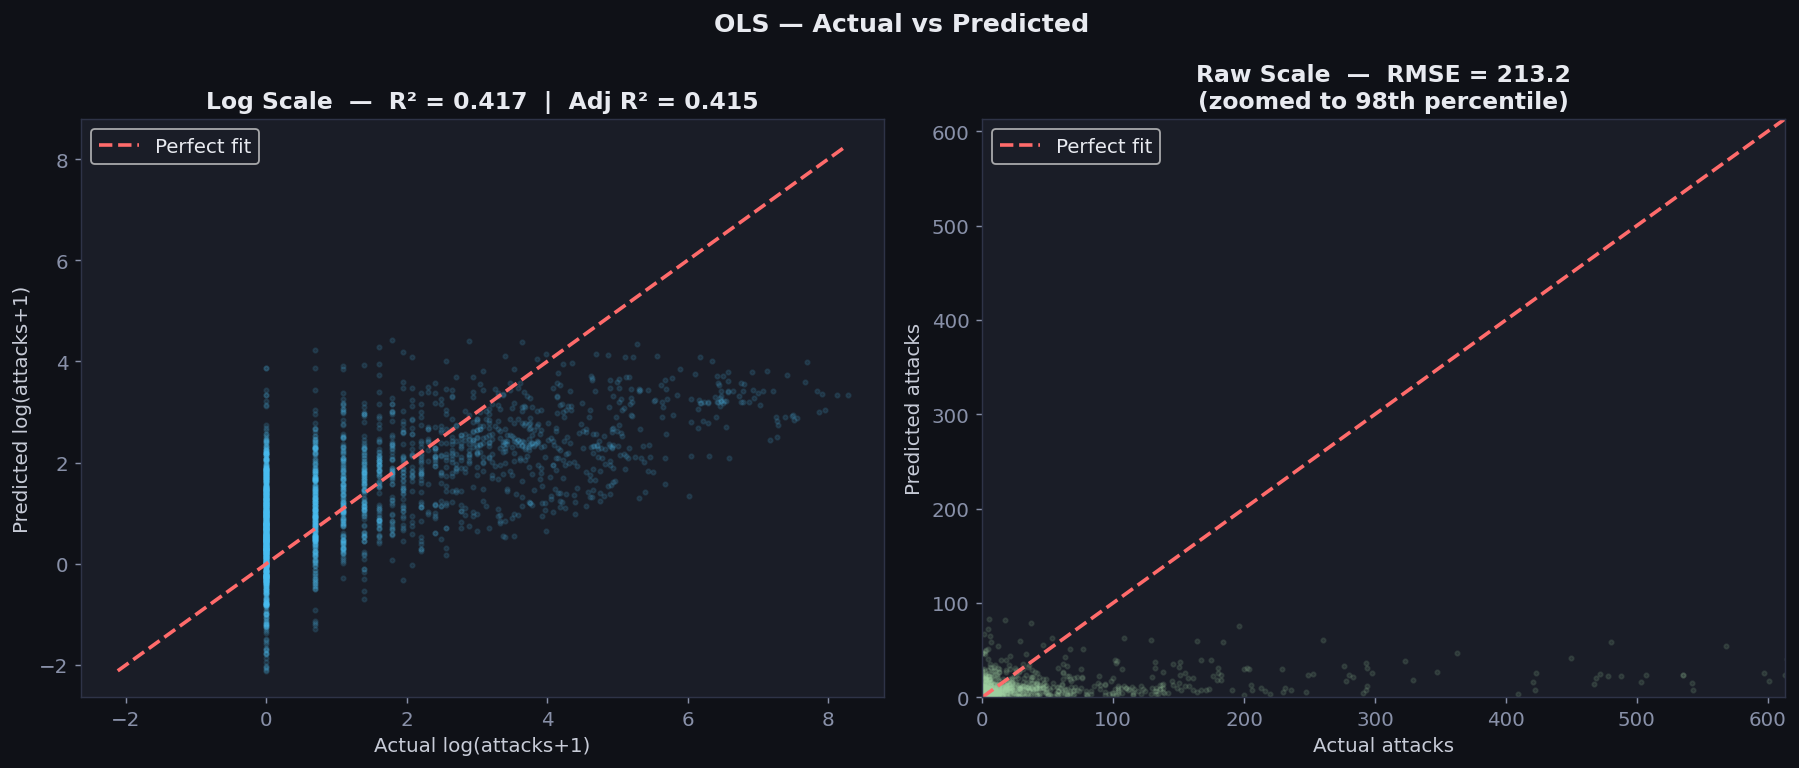


Summary metrics:
  R²                  = 0.4168
  Adjusted R²         = 0.4149
  RMSE (log scale)    = 1.3198
  MAE  (log scale)    = 1.0014
  RMSE (raw scale)    = 213.20 attacks


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log scale
ax = axes[0]
ax.scatter(y, y_pred, alpha=0.12, s=6, color=ACCENT)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, color=ACCENT2, lw=2, ls='--', label='Perfect fit')
ax.set_xlabel('Actual log(attacks+1)')
ax.set_ylabel('Predicted log(attacks+1)')
ax.set_title(f'Log Scale  —  R² = {r2:.3f}  |  Adj R² = {adj_r2:.3f}')
ax.legend()

# Raw scale (back-transform)
ax = axes[1]
y_raw   = sub['attacks'].values
y_pred_raw = np.maximum(np.expm1(y_pred), 0)
ax.scatter(y_raw, y_pred_raw, alpha=0.12, s=6, color=ACCENT3)
lims_r = [0, np.percentile(y_raw, 98)]  # zoom in to avoid outlier distortion
ax.plot(lims_r, lims_r, color=ACCENT2, lw=2, ls='--', label='Perfect fit')
ax.set_xlim(*lims_r); ax.set_ylim(*lims_r)
ax.set_xlabel('Actual attacks')
ax.set_ylabel('Predicted attacks')
rmse_raw = np.sqrt(mean_squared_error(y_raw, y_pred_raw))
ax.set_title(f'Raw Scale  —  RMSE = {rmse_raw:.1f}\n(zoomed to 98th percentile)')
ax.legend()

fig.suptitle('OLS — Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nSummary metrics:')
print(f'  R²                  = {r2:.4f}')
print(f'  Adjusted R²         = {adj_r2:.4f}')
print(f'  RMSE (log scale)    = {rmse:.4f}')
print(f'  MAE  (log scale)    = {mae:.4f}')
print(f'  RMSE (raw scale)    = {rmse_raw:.2f} attacks')

Goodness of Fit ($R^2 = 0.417$): Approximately 42% of the variation in the $\log(\text{attacks}+1)$ is explained by your model. While moderate, the "Adjusted $R^2$" ($0.415$) is very close, suggesting that your model is not overly cluttered with redundant predictors (despite the high VIFs noted earlier).

Systematic Under-prediction: At higher actual values (right side of the log plot), the data points consistently fall below the "Perfect fit" line. This indicates that the model is conservative; it severely underestimates the intensity of large-scale events.

Transformation Distortion (Raw Scale)

RMSE = 213.2: The Root Mean Square Error in raw units is extremely high relative to the mean. This is typical when using OLS on log-transformed count data.

The "Flattening" Effect: On the Raw Scale, the predicted values (y-axis) barely move while the actual values (x-axis) stretch to 600. The model is essentially predicting a narrow range of low values for almost every observation.

Jensen's Inequality: At an M.Sc. level, note that $E[\log(Y)] \neq \log(E[Y])$. Back-transforming OLS predictions from a log-scale to a raw scale introduces a systematic bias, usually resulting in the severe under-prediction seen here.

## 3.8 Coefficient plot — which predictors matter most?

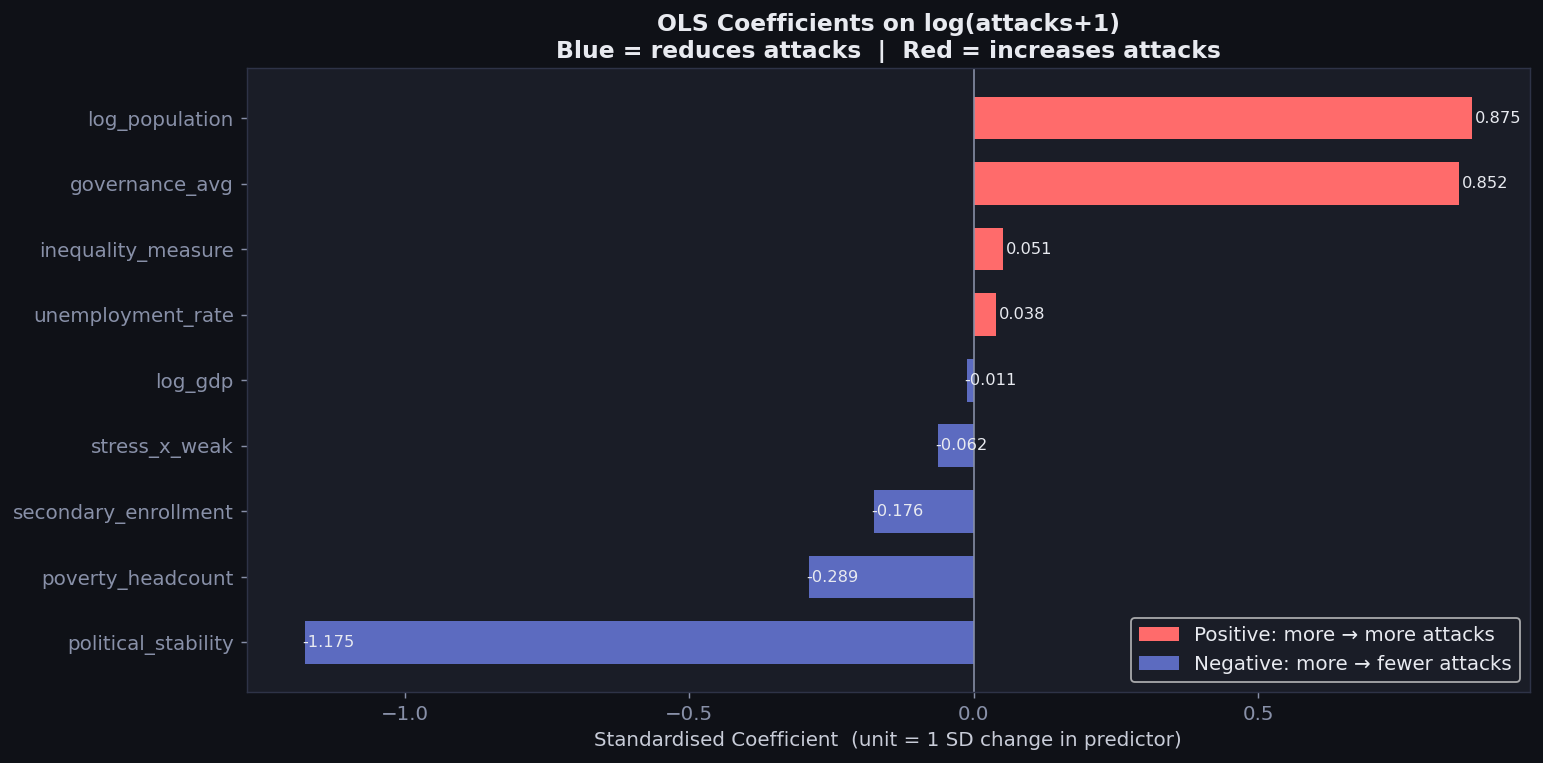

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
coef_sorted = coef_df.sort_values('Coefficient')
colors = [ACCENT2 if c > 0 else '#5c6bc0' for c in coef_sorted['Coefficient']]
bars = ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
               color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#8890a8', lw=0.9)
for bar, val in zip(bars, coef_sorted['Coefficient']):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#e8eaf0')
ax.set_xlabel('Standardised Coefficient  (unit = 1 SD change in predictor)')
ax.set_title('OLS Coefficients on log(attacks+1)\n'
             'Blue = reduces attacks  |  Red = increases attacks')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=ACCENT2,   label='Positive: more → more attacks'),
    Patch(facecolor='#5c6bc0', label='Negative: more → fewer attacks'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [10]:
# Save residuals and predictions for use in later notebooks
sub2 = sub.copy()
sub2['ols_pred_log'] = y_pred
sub2['ols_residual'] = residuals
sub2.to_csv('df_ols.csv', index=False)
print('OLS diagnostics complete. Saved to /tmp/df_ols.csv')
print('Ready for Step 4 ✓')

OLS diagnostics complete. Saved to /tmp/df_ols.csv
Ready for Step 4 ✓


Modelling dataset: 2,742 rows | Target: log_attacks


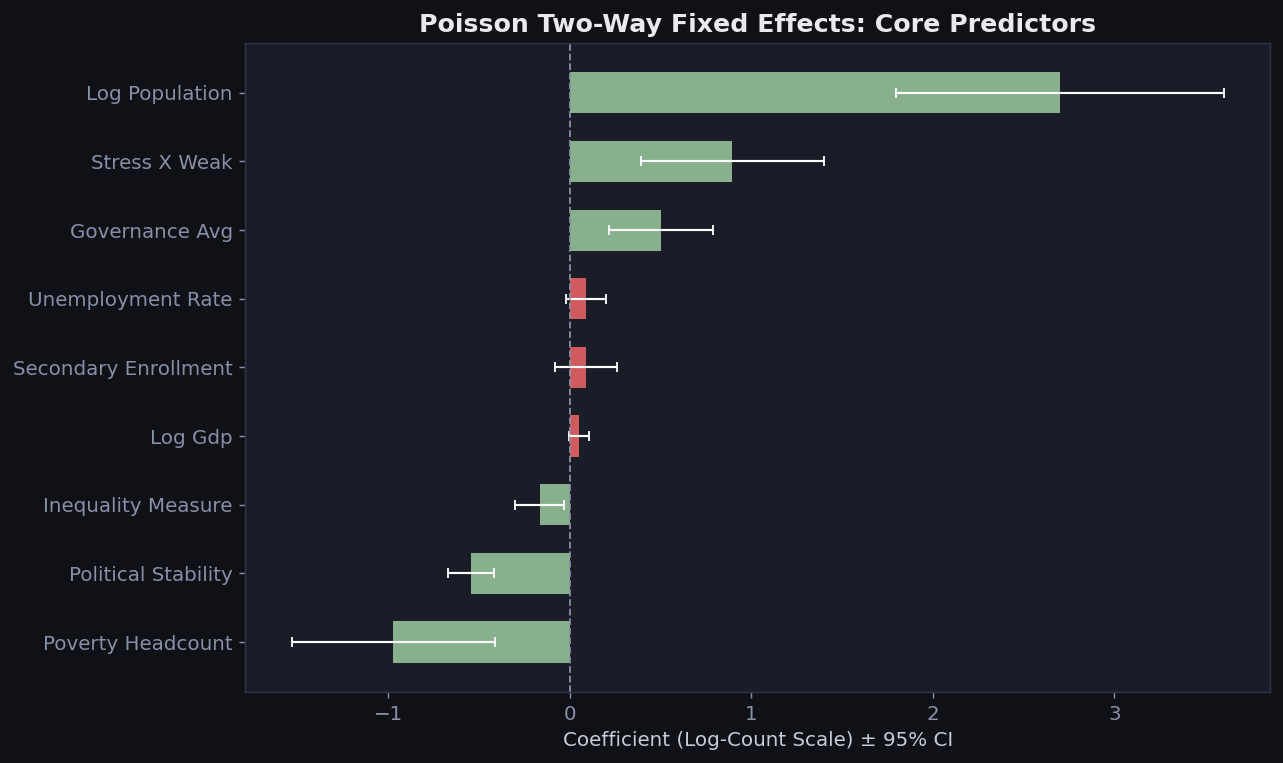


Model Fit Comparison (Lower AIC is better):
        Model         AIC  Log-Likelihood    Deviance
   Two-Way FE 4855.291571    -2257.645786 1565.766597
   Country FE 4926.105356    -2314.052678 1678.580382
Plain Poisson 6308.264808    -3144.132404 3338.739834


In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Presentation theme (Matches your snippet) ────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT, ACCENT2, SIG_CLR, NSIG_CLR = '#4fc3f7', '#ff6b6b', '#a5d6a7', '#ff6b6b'

# ── Load data ─────────────────────────────────────────────────────────────────
# Assuming df_features.csv is in the current directory
df = pd.read_csv('df_features.csv')

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
# TARGET for Poisson must be the raw integer count
TARGET_COUNT = 'log_attacks' 

sub = df[FEATURES + [TARGET_COUNT, 'country', 'year']].dropna().reset_index(drop=True)
sub[TARGET_COUNT] = sub[TARGET_COUNT].astype(int)

# Scale predictors for GLM convergence
scaler = StandardScaler()
X_s = pd.DataFrame(scaler.fit_transform(sub[FEATURES]), columns=FEATURES)
y = sub[TARGET_COUNT].values

print(f'Modelling dataset: {len(sub):,} rows | Target: {TARGET_COUNT}')

# ── 1. Helper: Poisson Regression Significance ────────────────────────────────
def fit_poisson_glm(X_fit, y_fit, feature_names):
    X_const = sm.add_constant(X_fit)
    # Using Poisson Link Function
    model = sm.GLM(y_fit, X_const, family=sm.families.Poisson()).fit()
    
    # Extract only the core features (ignore constant and dummy variables)
    res_df = pd.DataFrame({
        'Feature': ['intercept'] + list(feature_names),
        'Coef': model.params.values,
        'P-Value': model.pvalues.values,
        'Conf_Lower': model.conf_int()[0].values,
        'Conf_Upper': model.conf_int()[1].values
    })
    return res_df, model

# ── 2. Run Models ────────────────────────────────────────────────────────────

# A. Plain Poisson
res_plain_df, model_plain = fit_poisson_glm(X_s, y, FEATURES)

# B. Country Fixed Effects (LSDV Approach)
country_dummies = pd.get_dummies(sub['country'], drop_first=True, prefix='cfe').astype(float)
X_cfe = pd.concat([X_s, country_dummies], axis=1)
res_cfe_df, model_cfe = fit_poisson_glm(X_cfe, y, X_cfe.columns)

# C. Two-Way Fixed Effects (Country + Year)
year_dummies = pd.get_dummies(sub['year'], drop_first=True, prefix='yfe').astype(float)
X_twfe = pd.concat([X_s, country_dummies, year_dummies], axis=1)
res_twfe_df, model_twfe = fit_poisson_glm(X_twfe, y, X_twfe.columns)

# ── 3. Visualization: Two-Way FE Results ─────────────────────────────────────
# Only visualize core features for clarity
core_results = res_twfe_df[res_twfe_df['Feature'].isin(FEATURES)].sort_values('Coef')

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(core_results))
colors = [SIG_CLR if p < 0.05 else NSIG_CLR for p in core_results['P-Value']]

ax.barh(y_pos, core_results['Coef'], color=colors, alpha=0.8, height=0.6)
ax.errorbar(core_results['Coef'], y_pos, 
            xerr=[core_results['Coef'] - core_results['Conf_Lower'], 
                  core_results['Conf_Upper'] - core_results['Coef']], 
            fmt='none', color='white', capsize=3, lw=1.2)

ax.axvline(0, color='#8890a8', lw=1, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('_', ' ').title() for f in core_results['Feature']])
ax.set_title("Poisson Two-Way Fixed Effects: Core Predictors", fontsize=14)
ax.set_xlabel('Coefficient (Log-Count Scale) ± 95% CI')

plt.tight_layout()
plt.show()

# ── 4. Model Comparison ──────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Model": ["Plain Poisson", "Country FE", "Two-Way FE"],
    "AIC": [model_plain.aic, model_cfe.aic, model_twfe.aic],
    "Log-Likelihood": [model_plain.llf, model_cfe.llf, model_twfe.llf],
    "Deviance": [model_plain.deviance, model_cfe.deviance, model_twfe.deviance]
}).sort_values('AIC')

print("\nModel Fit Comparison (Lower AIC is better):")
print(comparison.to_string(index=False))

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Setup Data
df = pd.read_csv('df_features.csv')
FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]

sub = df[FEATURES + ['attacks', 'country', 'year']].dropna().reset_index(drop=True)
y = sub['attacks'].astype(int)
X_base = StandardScaler().fit_transform(sub[FEATURES])

# 2. Define the Null Model (Intercept only) for McFadden's R2
null_model = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Poisson()).fit()
ll_null = null_model.llf

def get_poisson_metrics(X, y_true, model_name):
    """Fits model and returns McFadden R2 and Predictive R2."""
    X_const = sm.add_constant(X)
    model = sm.GLM(y_true, X_const, family=sm.families.Poisson()).fit()
    
    # McFadden's Pseudo R2: 1 - (LL_full / LL_null)
    mcfadden = 1 - (model.llf / ll_null)
    
    # Predictive R2: Correlation(actual, predicted)^2
    y_pred = model.predict(X_const)
    predictive_r2 = np.corrcoef(y_true, y_pred)[0, 1]**2
    
    return {'Model': model_name, 'McFadden_R2': mcfadden, 'Predictive_R2': predictive_r2}

# 3. Calculate for different specifications
results = []

# A. Plain Poisson
results.append(get_poisson_metrics(X_base, y, "Plain Poisson"))

# B. Country Fixed Effects
cfe_dummies = pd.get_dummies(sub['country'], drop_first=True).astype(float)
X_cfe = np.hstack([X_base, cfe_dummies.values])
results.append(get_poisson_metrics(X_cfe, y, "Country FE"))

# C. Two-Way Fixed Effects (Country + Year)
yfe_dummies = pd.get_dummies(sub['year'], drop_first=True).astype(float)
X_twfe = np.hstack([X_base, cfe_dummies.values, yfe_dummies.values])
results.append(get_poisson_metrics(X_twfe, y, "Two-Way FE"))

# 4. Display Results
summary_df = pd.DataFrame(results)
print("=== Poisson Regression R-Squared Outcomes ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

=== Poisson Regression R-Squared Outcomes ===
        Model  McFadden_R2  Predictive_R2
Plain Poisson       0.5659         0.2302
   Country FE       0.8909         0.8182
   Two-Way FE       0.9166         0.9008


Observations (y): 2742
Predictors (X):   170


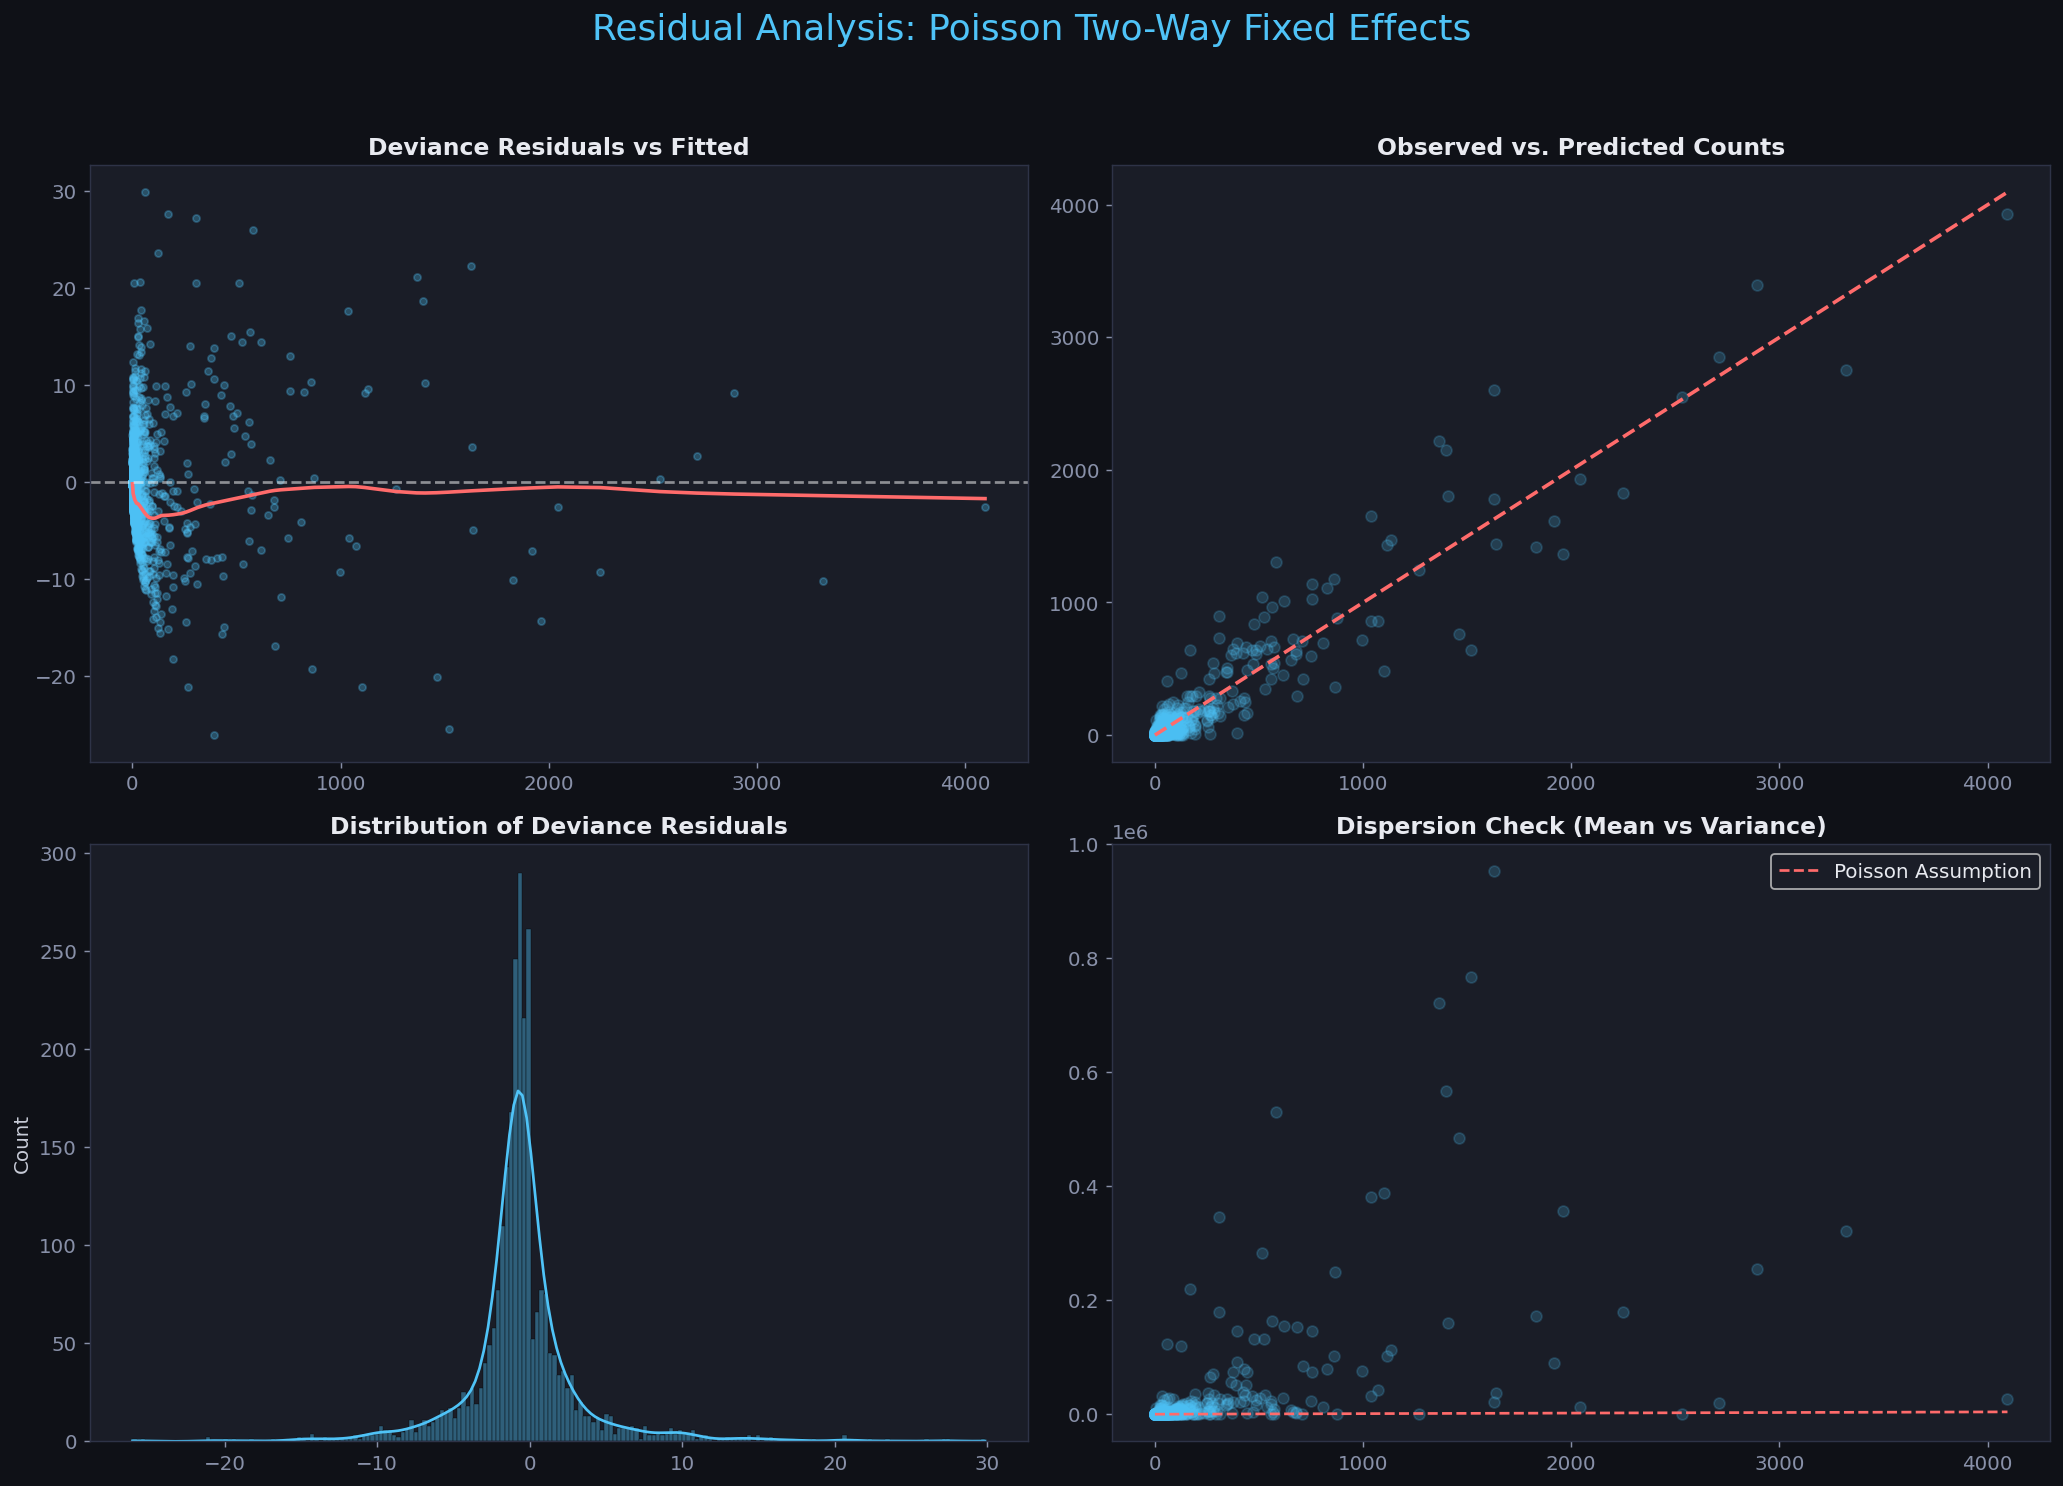

Final Dispersion Ratio: 22.5253


In [21]:
# ── 5. Final Synchronized Model & Residual Analysis ───────────────────────

# 1. Re-initialize names if they were lost in the session
TARGET_VAR = 'attacks'
# Using PREDICTORS as defined in your first block
FEATURES_LIST = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]

# 2. Clean slice: Use .copy() to avoid SettingWithCopy warnings
sub = df[FEATURES_LIST + [TARGET_VAR, 'country', 'year']].dropna().copy()

# 3. Re-generate Y (the target counts)
y_final = sub[TARGET_VAR].astype(int).values

# 4. Re-generate X components from the SAME 'sub' slice
X_base_scaled = StandardScaler().fit_transform(sub[FEATURES_LIST])

# Fixed Effects (Dummies) - ensuring float type for statsmodels
cfe_vars = pd.get_dummies(sub['country'], drop_first=True).values.astype(float)
yfe_vars = pd.get_dummies(sub['year'], drop_first=True).values.astype(float)

# 5. Combine everything into the final feature matrix
X_final = np.hstack([X_base_scaled, cfe_vars, yfe_vars])
X_final = sm.add_constant(X_final)

# --- Final Size Check ---
print(f"Observations (y): {y_final.shape[0]}")
print(f"Predictors (X):   {X_final.shape[1]}")

# 6. Fit the GLM (Poisson)
best_model = sm.GLM(y_final, X_final, family=sm.families.Poisson()).fit()

# 7. Calculate Residuals
mu = best_model.predict(X_final)
deviance_resid = best_model.resid_deviance

# ── Visual Proofs ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Deviance Residuals vs Fitted
# Purpose: Check for non-linear patterns.
axes[0, 0].scatter(mu, deviance_resid, color=ACCENT, alpha=0.3, s=15)
sns.regplot(x=mu, y=deviance_resid, lowess=True, ax=axes[0, 0], 
            scatter=False, line_kws={'color': ACCENT2, 'lw': 2})
axes[0, 0].axhline(0, color='white', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Deviance Residuals vs Fitted', fontweight='bold')

# Plot 2: Observed vs. Predicted
# Purpose: See how well the model tracks the identity line.
axes[0, 1].scatter(mu, y_final, color=ACCENT, alpha=0.2)
limit = max(y_final.max(), mu.max())
axes[0, 1].plot([0, limit], [0, limit], color=ACCENT2, linestyle='--', lw=2)
axes[0, 1].set_title('Observed vs. Predicted Counts', fontweight='bold')

# Plot 3: Distribution of Deviance Residuals
# Purpose: Check for normality of errors (ideal but not strictly required for Poisson).
sns.histplot(deviance_resid, kde=True, ax=axes[1, 0], color=ACCENT, alpha=0.4)
axes[1, 0].set_title('Distribution of Deviance Residuals', fontweight='bold')

# Plot 4: Dispersion Check
# Purpose: Verify the Poisson assumption (Mean = Variance).
axes[1, 1].scatter(mu, (y_final - mu)**2, color=ACCENT, alpha=0.2)
axes[1, 1].plot([0, limit], [0, limit], color=ACCENT2, linestyle='--', label='Poisson Assumption')
axes[1, 1].set_title('Dispersion Check (Mean vs Variance)', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Residual Analysis: Poisson Two-Way Fixed Effects', fontsize=20, y=0.98, color=ACCENT)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ── Statistical Diagnostic ──
dispersion = best_model.pearson_chi2 / best_model.df_resid
print(f"Final Dispersion Ratio: {dispersion:.4f}")
if dispersion > 1.2:
    print("WARNING: Data is Overdispersed. P-values may be overly optimistic.")

--- Individual Predictor Residual Check ---


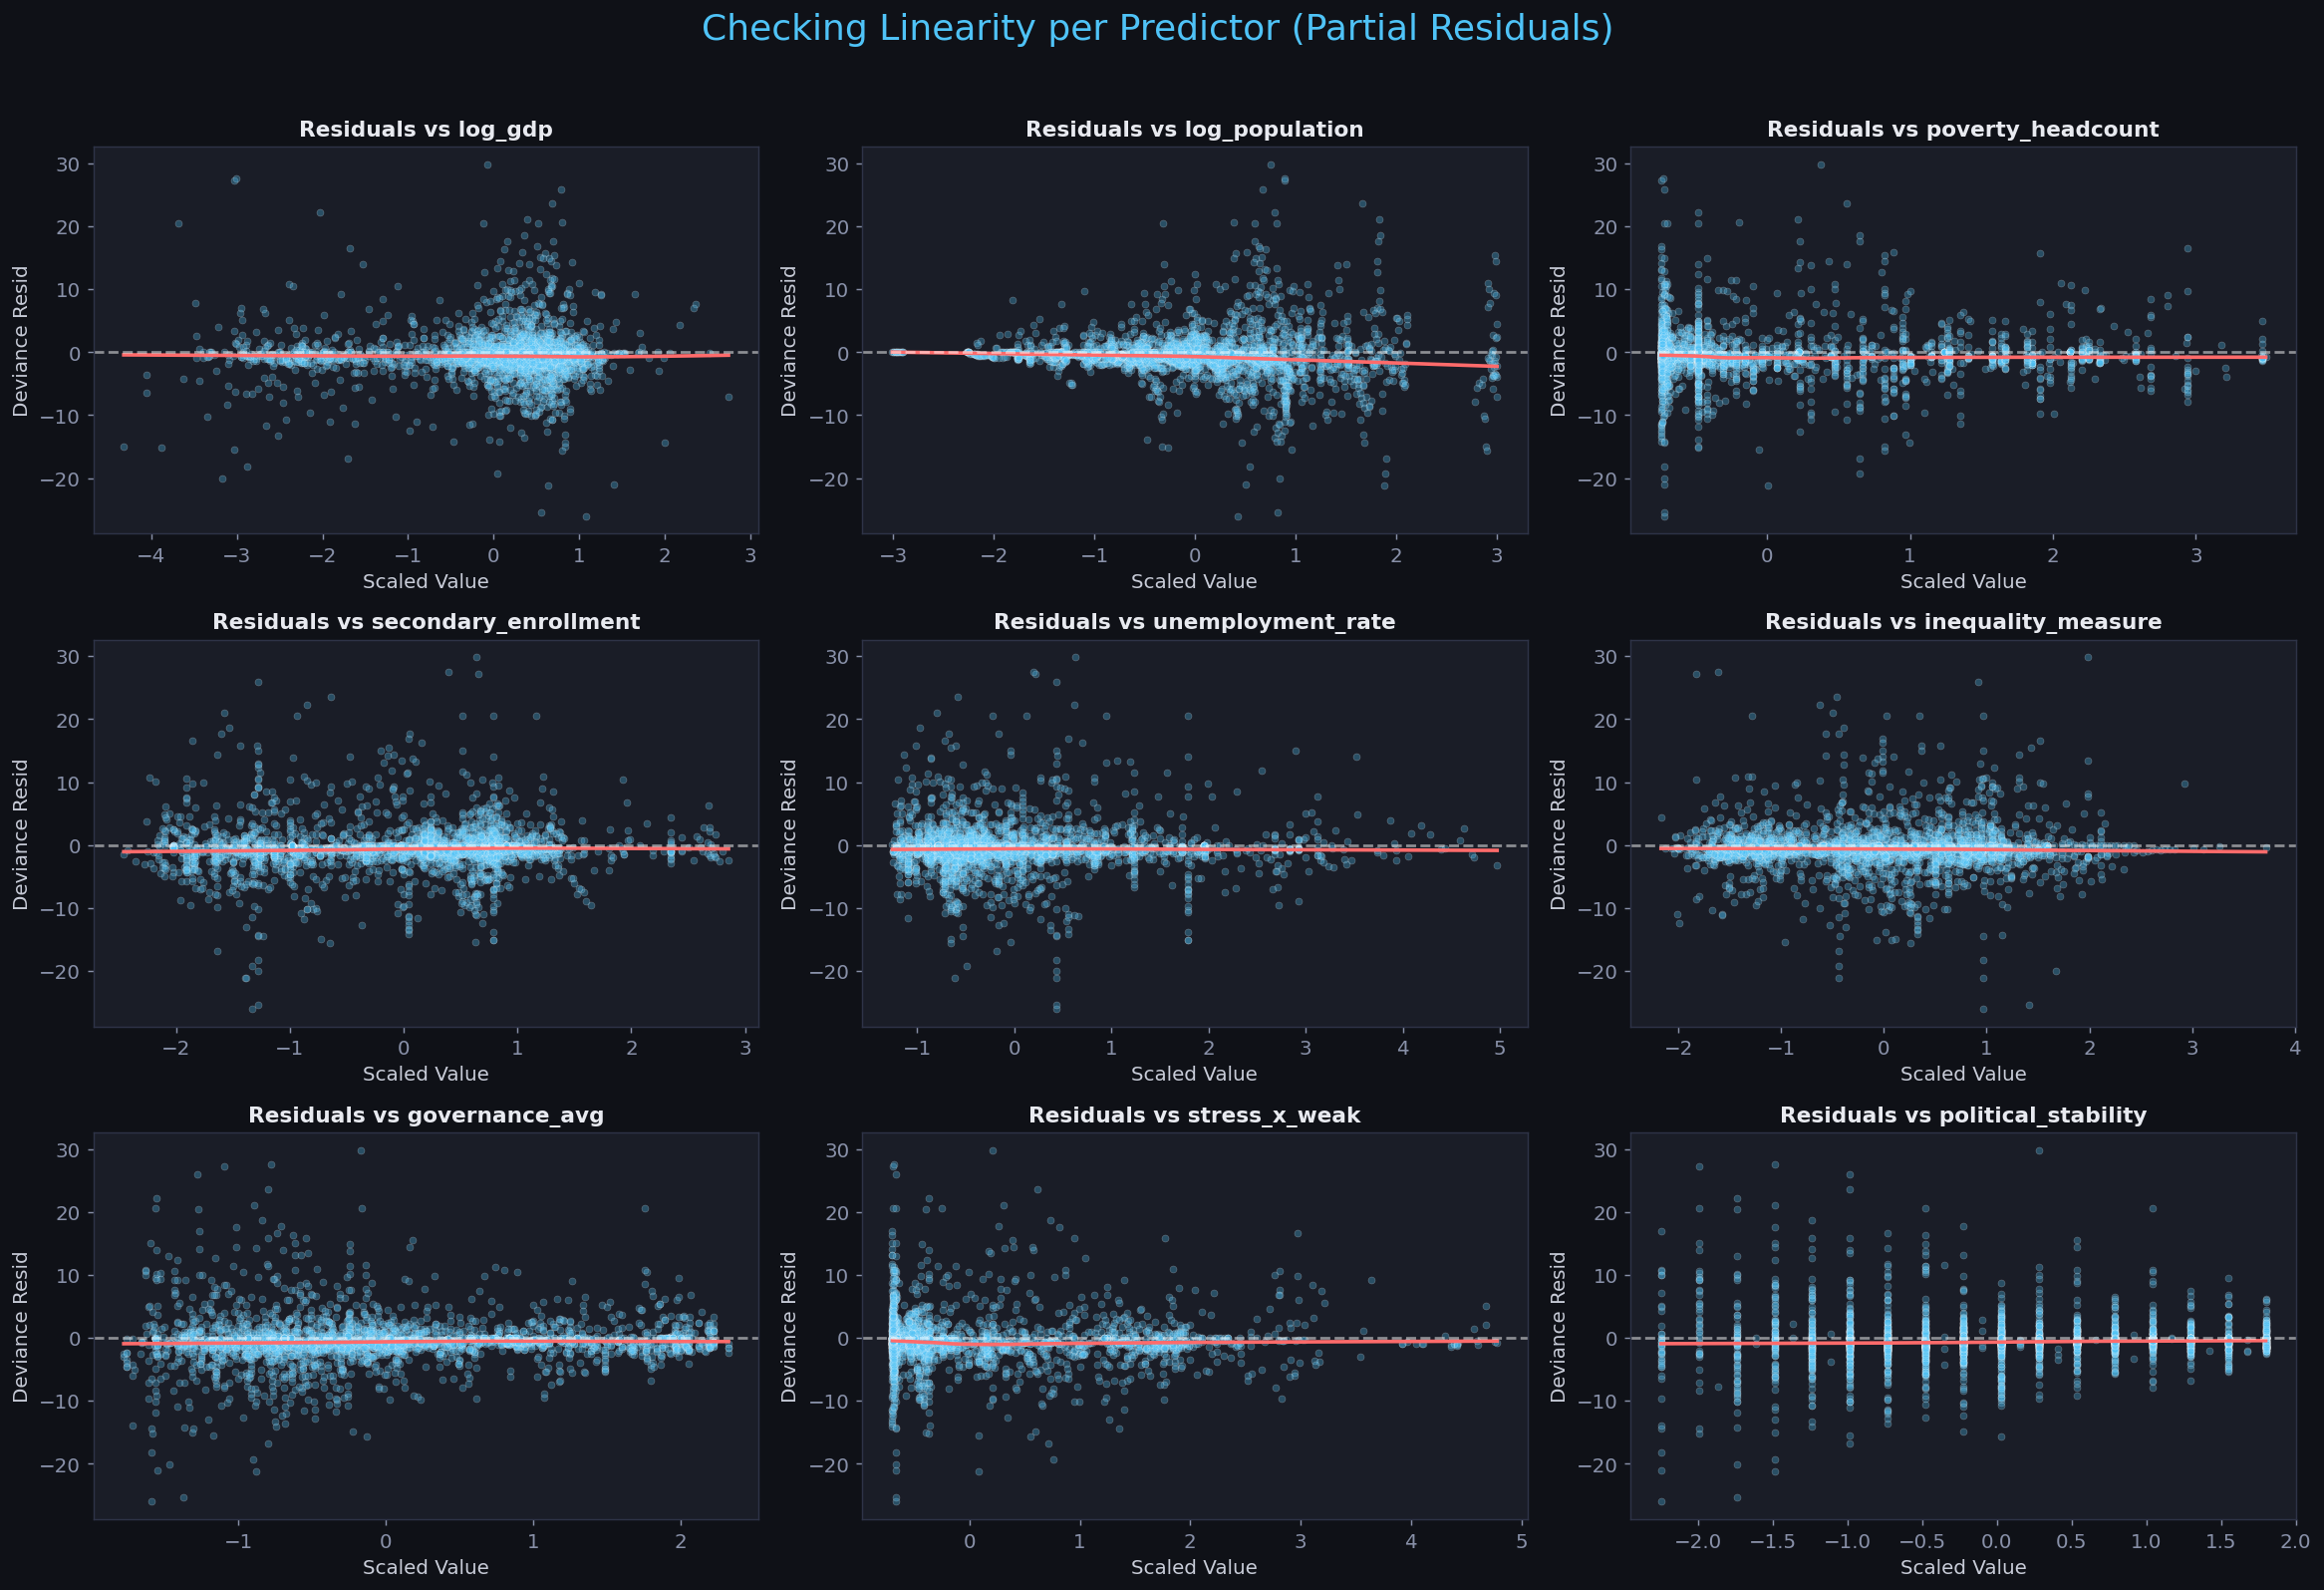

In [22]:
# ── 6. Individual Feature Residual Analysis ──────────────────────────────────
import math

# Calculate the number of rows needed for the grid
n_feats = len(FEATURES_LIST)
n_cols = 3
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

print("--- Individual Predictor Residual Check ---")

for i, col in enumerate(FEATURES_LIST):
    # Extract the specific feature column from our scaled matrix
    # (The index i corresponds to the order in FEATURES_LIST)
    x_val = X_base_scaled[:, i]
    
    # Plot Feature vs. Deviance Residuals
    sns.scatterplot(x=x_val, y=deviance_resid, ax=axes[i], color=ACCENT, alpha=0.3, s=15)
    sns.regplot(x=x_val, y=deviance_resid, lowess=True, ax=axes[i], 
                scatter=False, line_kws={'color': ACCENT2, 'lw': 2})
    
    axes[i].axhline(0, color='white', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Residuals vs {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Deviance Resid')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Checking Linearity per Predictor (Partial Residuals)', fontsize=20, y=1.02, color=ACCENT)
plt.tight_layout()
plt.show()

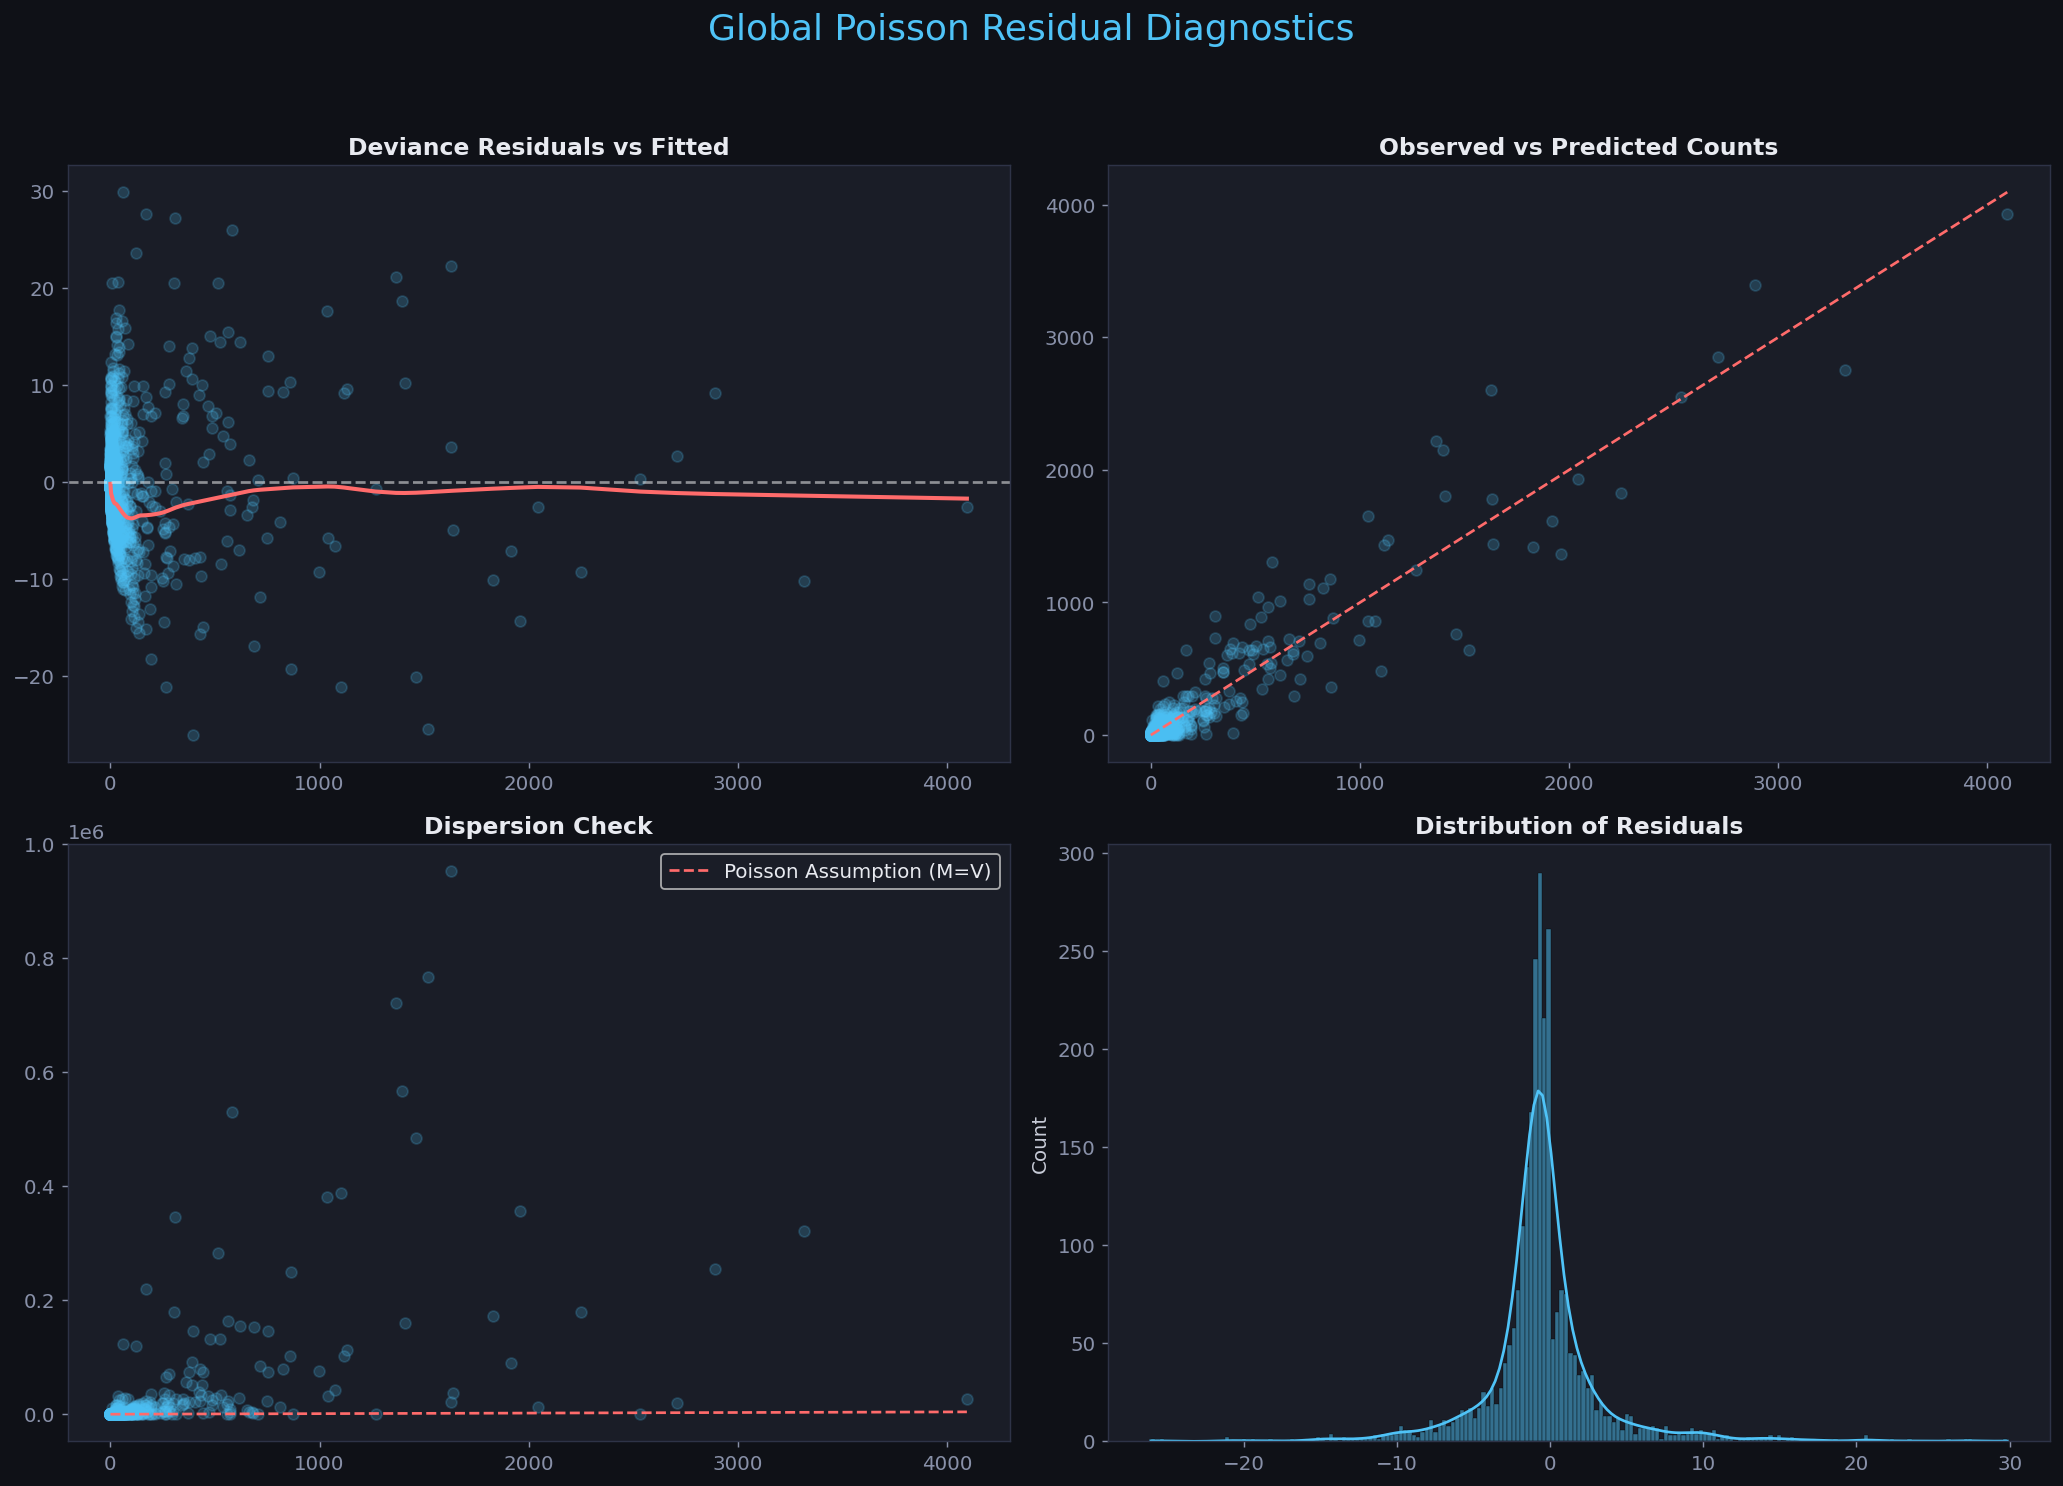

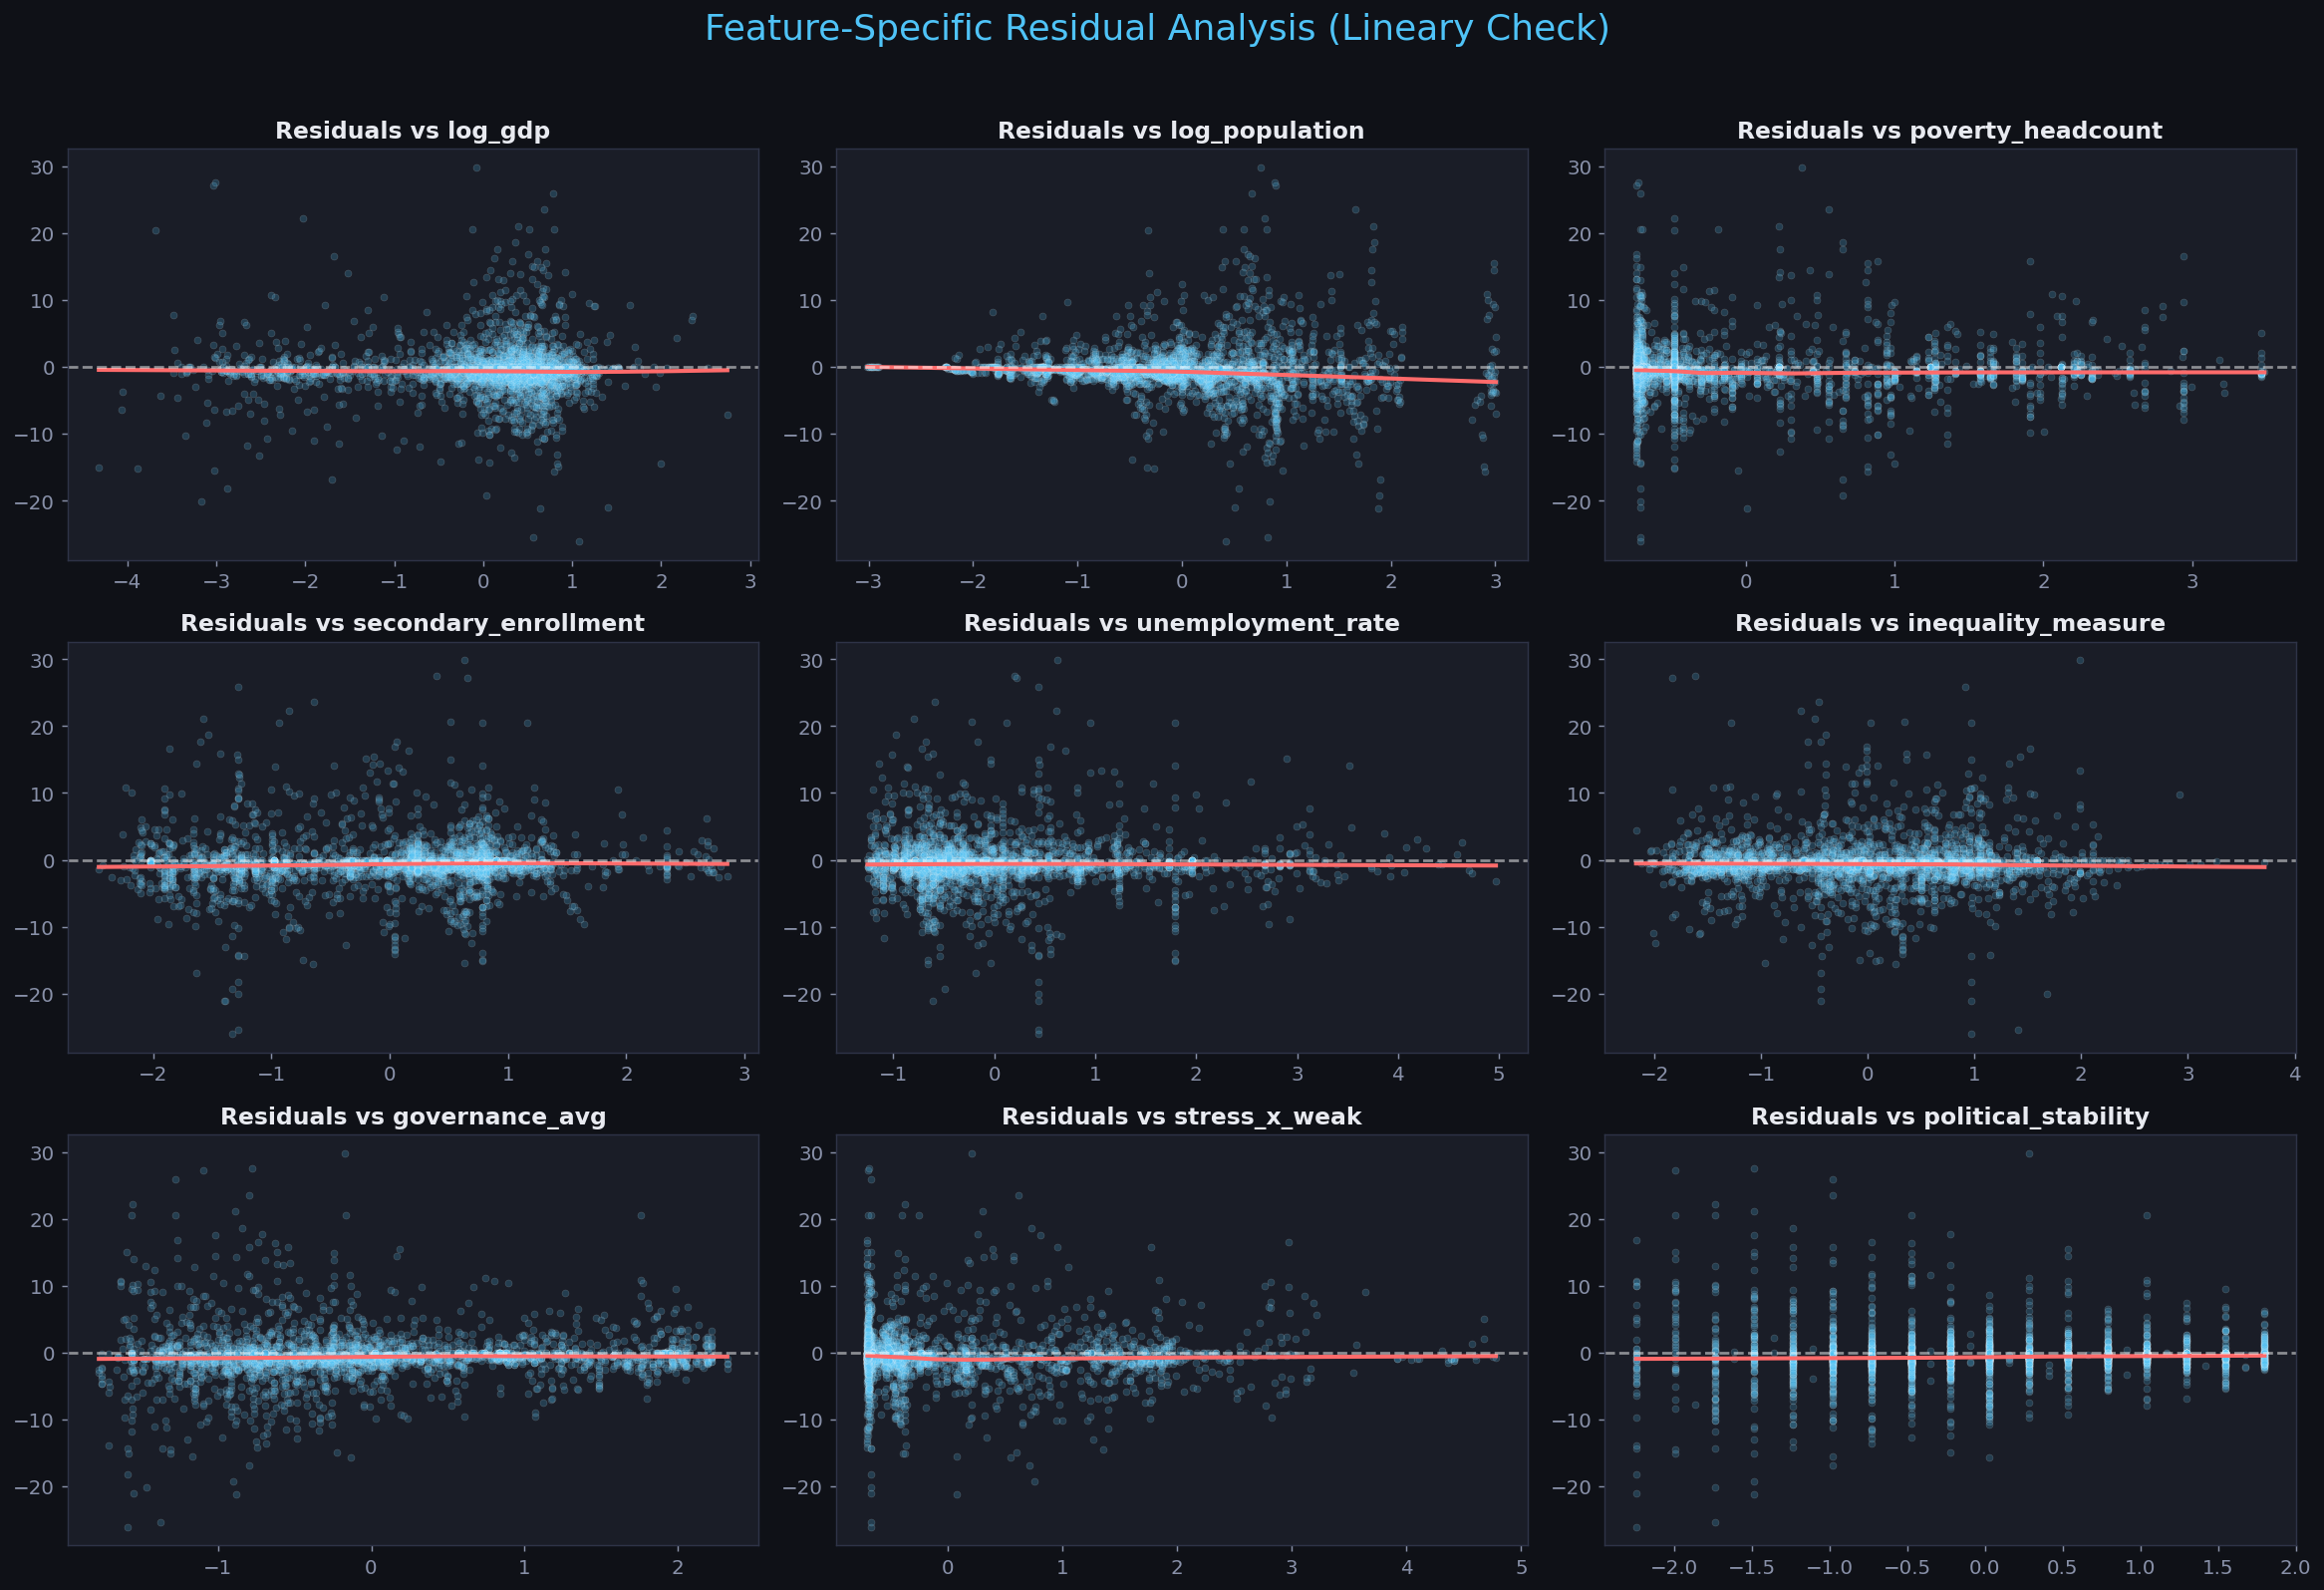


Final Dispersion Ratio: 22.5253


In [24]:
# ── Setup Constants & Data ──
# Redefining these to prevent NameErrors
PREDICTORS_FINAL = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_VAR = 'attacks'

# 1. Synchronized Data Cleaning
# We use .copy() to ensure 'sub' is an independent dataframe
sub = df[PREDICTORS_FINAL + [TARGET_VAR, 'country', 'year']].dropna().copy()
y_final = sub[TARGET_VAR].astype(int).values

# 2. Reconstruct X Matrix (Scaling + Fixed Effects)
X_base_scaled = StandardScaler().fit_transform(sub[PREDICTORS_FINAL])
cfe_vars = pd.get_dummies(sub['country'], drop_first=True).values.astype(float)
yfe_vars = pd.get_dummies(sub['year'], drop_first=True).values.astype(float)

X_final = np.hstack([X_base_scaled, cfe_vars, yfe_vars])
X_final = sm.add_constant(X_final)

# 3. Fit Poisson TWFE Model
best_model = sm.GLM(y_final, X_final, family=sm.families.Poisson()).fit()
mu = best_model.predict(X_final)
deviance_resid = best_model.resid_deviance

# ── Part A: Global Diagnostic Dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Deviance Residuals vs Fitted (Link Function Check)
sns.regplot(x=mu, y=deviance_resid, lowess=True, ax=axes[0,0], 
            scatter_kws={'alpha': 0.2, 'color': ACCENT}, line_kws={'color': ACCENT2})
axes[0,0].axhline(0, color='white', linestyle='--', alpha=0.5)
axes[0,0].set_title('Deviance Residuals vs Fitted', fontweight='bold')

# Plot 2: Observed vs Predicted (Model Accuracy)
axes[0,1].scatter(mu, y_final, alpha=0.2, color=ACCENT)
limit = max(y_final.max(), mu.max())
axes[0,1].plot([0, limit], [0, limit], '--', color=ACCENT2)
axes[0,1].set_title('Observed vs Predicted Counts', fontweight='bold')

# Plot 3: Dispersion Check (Mean vs Variance)
axes[1,0].scatter(mu, (y_final - mu)**2, alpha=0.2, color=ACCENT)
axes[1,0].plot([0, limit], [0, limit], '--', color=ACCENT2, label='Poisson Assumption (M=V)')
axes[1,0].set_title('Dispersion Check', fontweight='bold')
axes[1,0].legend()

# Plot 4: Distribution of Deviance Residuals
sns.histplot(deviance_resid, kde=True, ax=axes[1,1], color=ACCENT)
axes[1,1].set_title('Distribution of Residuals', fontweight='bold')

plt.suptitle('Global Poisson Residual Diagnostics', fontsize=20, y=0.98, color=ACCENT)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ── Part B: Individual Feature vs. Residuals ──
# This checks if specific variables are causing non-linear issues
n_feats = len(PREDICTORS_FINAL)
n_cols = 3
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(PREDICTORS_FINAL):
    x_val = X_base_scaled[:, i]
    sns.scatterplot(x=x_val, y=deviance_resid, ax=axes[i], color=ACCENT, alpha=0.2, s=15)
    sns.regplot(x=x_val, y=deviance_resid, lowess=True, ax=axes[i], scatter=False, line_kws={'color': ACCENT2})
    axes[i].axhline(0, color='white', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Residuals vs {col}', fontweight='bold')

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

plt.suptitle('Feature-Specific Residual Analysis (Lineary Check)', fontsize=20, y=1.02, color=ACCENT)
plt.tight_layout()
plt.show()

# ── Final Diagnostic Metric ──
dispersion_ratio = best_model.pearson_chi2 / best_model.df_resid
print(f"\nFinal Dispersion Ratio: {dispersion_ratio:.4f}")

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Load and Prepare Data (Ensuring all variables are defined in this block)
df = pd.read_csv('df_features.csv')

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]

# Drop NAs and define target
sub = df[FEATURES + ['attacks', 'country', 'year']].dropna().reset_index(drop=True)
y = sub['attacks'].astype(int)

# Standardize core features
scaler = StandardScaler()
X_s = pd.DataFrame(scaler.fit_transform(sub[FEATURES]), columns=FEATURES)

# Create Dummy Variables for Fixed Effects
country_dummies = pd.get_dummies(sub['country'], drop_first=True, prefix='cfe').astype(float)
year_dummies = pd.get_dummies(sub['year'], drop_first=True, prefix='yfe').astype(float)

# Define the three model matrices
X_plain = X_s
X_cfe   = pd.concat([X_s, country_dummies], axis=1)
X_twfe  = pd.concat([X_s, country_dummies, year_dummies], axis=1)

# 2. Verification Function
def verify_poisson(X, y_true, model_name):
    X_const = sm.add_constant(X)
    model = sm.GLM(y_true, X_const, family=sm.families.Poisson()).fit()
    
    # Calculate Dispersion Ratio (Pearson Chi2 / Degrees of Freedom)
    ratio = model.pearson_chi2 / model.df_resid
    
    return {
        "Model": model_name,
        "Dispersion Ratio": ratio,
        "Verdict": "Extremely Overdispersed" if ratio > 2 else "Valid"
    }

# 3. Execute and Print Results
verification_results = []
verification_results.append(verify_poisson(X_plain, y, "Plain Poisson"))
verification_results.append(verify_poisson(X_cfe, y, "Country FE"))
verification_results.append(verify_poisson(X_twfe, y, "Two-Way FE"))

print("=== FINAL POISSON VERIFICATION ===")
print(pd.DataFrame(verification_results).to_string(index=False))

# Calculate Target Stats
print(f"\nRaw Variance/Mean Ratio: {y.var()/y.mean():.2f}")

=== FINAL POISSON VERIFICATION ===
        Model  Dispersion Ratio                 Verdict
Plain Poisson        152.016159 Extremely Overdispersed
   Country FE         33.490009 Extremely Overdispersed
   Two-Way FE         22.525251 Extremely Overdispersed

Raw Variance/Mean Ratio: 1083.17


In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
df = pd.read_csv('df_features.csv')
FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]

sub = df[FEATURES + ['attacks', 'country', 'year']].dropna().reset_index(drop=True)
y = sub['attacks'].astype(int)
X_base = sm.add_constant(pd.DataFrame(StandardScaler().fit_transform(sub[FEATURES]), columns=FEATURES))

# 2. Fit Negative Binomial Models
# We use sm.NegativeBinomial because it estimates 'alpha' (dispersion) automatically
def run_nb2(X, y_true, name):
    print(f"Fitting {name}...")
    # 'nb2' specifies the standard variance function: V = mu + alpha * mu^2
    model = sm.NegativeBinomial(y_true, X, loglike_method='nb2').fit(disp=0)
    
    # Metrics
    mcfadden = model.prsquared
    y_pred = model.predict(X)
    pred_r2 = np.corrcoef(y_true, y_pred)[0, 1]**2
    alpha = model.params['alpha']
    
    return {'Model': name, 'McFadden_R2': mcfadden, 'Predictive_R2': pred_r2, 'Alpha': alpha}

# 3. Compare Specifications
results_nb = []
results_nb.append(run_nb2(X_base, y, "NB2 Plain"))

# For Fixed Effects (NB can be slow with 100+ dummies, so we use core features + selection)
country_dummies = pd.get_dummies(sub['country'], drop_first=True).astype(float)
X_cfe = pd.concat([X_base, country_dummies], axis=1)
results_nb.append(run_nb2(X_cfe, y, "NB2 Country FE"))

# 4. Display Results
summary_nb = pd.DataFrame(results_nb)
print("\n=== Negative Binomial (Robust) Outcomes ===")
print(summary_nb.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Fitting NB2 Plain...
Fitting NB2 Country FE...

=== Negative Binomial (Robust) Outcomes ===
         Model  McFadden_R2  Predictive_R2  Alpha
     NB2 Plain       0.1091         0.0451 3.9135
NB2 Country FE       0.2129         0.7177 1.4907


In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Load and create Lagged Target
df = pd.read_csv('df_features.csv')
df = df.sort_values(['country', 'year'])
df['attacks_lag1'] = df.groupby('country')['attacks'].shift(1)

# Prepare subset (dropping the first year of each country because lag is NaN)
sub = df.dropna(subset=['attacks_lag1'] + FEATURES).reset_index(drop=True)
y = sub['attacks'].astype(int)

# 2. Setup Predictors
X_core = pd.DataFrame(StandardScaler().fit_transform(sub[FEATURES]), columns=FEATURES)
X_lag  = sub[['attacks_lag1']].reset_index(drop=True)
cfe    = pd.get_dummies(sub['country'], drop_first=True, prefix='cfe').astype(float)
yfe    = pd.get_dummies(sub['year'], drop_first=True, prefix='yfe').astype(float)

# 3. Define the "Best" Model: Dynamic Two-Way FE
# This combines: Economic features + History (Lag) + Country Traits + Year Shocks
X_final = pd.concat([X_core, X_lag, cfe, yfe], axis=1)
X_final = sm.add_constant(X_final)

# Fit NB2
model_final = sm.NegativeBinomial(y, X_final, loglike_method='nb2').fit(disp=0)

# 4. Display Results
print(f"Improved McFadden R2:  {model_final.prsquared:.4f}")
y_pred = model_final.predict(X_final)
print(f"Improved Predictive R2: {np.corrcoef(y, y_pred)[0, 1]**2:.4f}")
print(f"Dispersion (Alpha):     {model_final.params['alpha']:.4f}")

Improved McFadden R2:  0.2522
Improved Predictive R2: 0.4421
Dispersion (Alpha):     1.0183


In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Load and Advanced Engineering
df = pd.read_csv('df_features.csv')
df = df.sort_values(['country', 'year'])

# A. Add Lagged Target (History is the best predictor)
df['attacks_lag1'] = df.groupby('country')['attacks'].shift(1)

# B. Add Quadratic Terms (for U-shaped relationships)
df['poverty_sq'] = df['poverty_headcount']**2
df['gdp_sq'] = df['log_gdp']**2

# C. Interaction (Poverty * Inequality)
df['pov_x_ineq'] = df['poverty_headcount'] * df['inequality_measure']

# Cleanup
adv_features = FEATURES + ['attacks_lag1', 'poverty_sq', 'gdp_sq', 'pov_x_ineq']
sub_adv = df.dropna(subset=adv_features).reset_index(drop=True)
y = sub_adv['attacks'].astype(int)

# 2. Setup Matrices
X_core = pd.DataFrame(StandardScaler().fit_transform(sub_adv[adv_features]), columns=adv_features)
cfe = pd.get_dummies(sub_adv['country'], drop_first=True).astype(float)
yfe = pd.get_dummies(sub_adv['year'], drop_first=True).astype(float)

X_final = pd.concat([X_core, cfe, yfe], axis=1)
X_final = sm.add_constant(X_final)

# 3. Fit and Predict
# Using 'cg' or 'bfgs' solver often helps with convergence in complex models
model_final = sm.NegativeBinomial(y, X_final, loglike_method='nb2').fit(method='bfgs', maxiter=100, disp=0)

# 4. Results
y_pred = model_final.predict(X_final)
pred_r2 = np.corrcoef(y, y_pred)[0, 1]**2

print(f"Non-Linear NB2 Predictive R2: {pred_r2:.4f}")
print(f"Non-Linear NB2 McFadden R2:   {model_final.prsquared:.4f}")

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1074: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1567: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + exposure + offset)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1568: RuntimeWarning: invalid value encountered in multiply
  return -np.dot(L*X.T, X)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1478: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + offset + exposure)


Non-Linear NB2 Predictive R2: nan
Non-Linear NB2 McFadden R2:   nan
